# **Comparativa de modelos de aprendizaje automático para la predicción e interpretación de la adherencia a tratamientos farmacológicos**


> Laia Navarro i Martínez

> Tipo 3: Comparativa de soluciones


Este cuaderno desarrolla el análisis completo del problema de la adherencia a tratamientos farmacológicos mediante técnicas de ciencia de datos y aprendizaje automático. El objetivo principal es comparar distintos modelos supervisados para predecir la adherencia de los pacientes, así como complementar el análisis con técnicas de interpretabilidad y segmentación.

El flujo de trabajo se estructura en las siguientes fases:

1. **Carga y comprensión del conjunto de datos**

Se importa el dataset para realizar una primera exploración con el objetivo de comprender su estructura y estudiar las variables disponibles.

2. **Análisis exploratorio de datos (EDA)**

Se analizan las distribuciones de las variables, posibles relaciones entre ellas y patrones relevantes que puedan influir en la adherencia al tratamiento.

3. **Preprocesamiento de datos**

Se preparan los datos para el modelado:

- Separación en variables predictoras y variable objetivo
- División en conjuntos de entrenamiento, validación y test
- Definición del pipeline para la transformación de variables numéricas y categóricas

4. **Aprendizaje supervisado: predicción de adherencia**

4.1. **Ajuste y comparación inicial de modelos supervisados**

Se entrenan y comparan distintos modelos de clasificación:

- Regresión Logística
- Random Forest
- Red neuronal (MLP)
- XGBoost

La comparación se realiza utilizando métricas como accuracy, precision, recall, F1-score y ROC-AUC.

4.2. **Ajuste del modelo seleccionado**

Se selecciona el modelo con mejor rendimiento (XGBoost) y se optimizan sus hiperparámetros mediante búsqueda aleatoria (RandomizedSearchCV).

4.3. **Optimización del umbral de decisión**

Se ajusta el threshold de clasificación utilizando el conjunto de validación, con el objetivo de mejorar el equilibrio entre precisión y recall, especialmente en la detección de pacientes no adherentes.

4.4. **Evaluación final sobre el conjunto de test**

Se evalúa el modelo final sobre el conjunto de test, obteniendo una estimación realista de su capacidad de generalización.

4.5. **Análisis del sobreajuste**

Se analiza el comportamiento del modelo mediante curvas de aprendizaje, comparando el rendimiento en entrenamiento y validación, con el objetivo de identificar posibles problemas de sobreajuste o infraajuste.

4.6. **Resumen de los modelos supervisados**

Se realiza una comparación global de los modelos evaluados, analizando sus resultados en términos de las métricas consideradas. Este análisis permite evaluar el rendimiento relativo de cada modelo y comprender sus diferencias en función de las métricas utilizadas.

5. **Aprendizaje No supervisado: segmentación de pacientes**

Se aplican técnicas de clustering para identificar perfiles de pacientes con comportamientos similares, complementando así el análisis predictivo con un enfoque descriptivo.

6. **Técnicas de interpretabilidad**

Se analizan las variables más relevantes que influyen en la predicción, con el objetivo de aportar interpretabilidad al modelo y facilitar la comprensión de los factores asociados a la adherencia.



## 1. Carga y comprensión del conjunto de datos

In [ ]:
# =========================================================
# IMPORTACIÓN DE LIBRERÍAS
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, silhouette_score

from scipy.stats import randint, uniform
from scipy.cluster.hierarchy import dendrogram, linkage
from xgboost import XGBClassifier
import shap

In [ ]:
# =========================================================
# DESCARGA DEL DATASET
# =========================================================
# Se descarga el dataset desde Kaggle utilizando kagglehub.
# Este paso es opcional y puede requerir conexión a internet.
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vipulshahi/patient-adherence-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'patient-adherence-dataset' dataset.
Path to dataset files: /kaggle/input/patient-adherence-dataset


In [ ]:
# =========================================================
# CARGA DEL DATASET
# =========================================================
# Se carga el conjunto de datos desde el archivo CSV

# Cargar datos
df = pd.read_csv(path + "/patient_adherence_dataset.csv")

# Cargar datos
display(df.head())

,Age,Gender,Medication_Type,Dosage_mg,Previous_Adherence,Education_Level,Income,Social_Support_Level,Condition_Severity,Comorbidities_Count,Healthcare_Access,Mental_Health_Status,Insurance_Coverage,Adherence
0,57,Male,TypeA,136,1,High School,634934,Medium,Severe,3,Poor,Good,1,1
1,47,Male,TypeA,134,1,High School,297954,High,Moderate,3,Good,Good,1,0
2,59,Male,TypeC,89,1,High School,789337,High,Moderate,1,Good,Good,1,1
3,72,Male,TypeB,240,0,Postgraduate,267352,Low,Mild,2,Poor,Moderate,1,0
4,46,Male,TypeA,241,1,Postgraduate,718447,Medium,Mild,1,Poor,Good,1,0


El conjunto de datos utilizado en este estudio se obtiene a partir de un repositorio público disponible en Kaggle. Para facilitar la reproducibilidad, el dataset se descarga y se incluye en el entorno de trabajo.

Este dataset contiene información clínica, demográfica y conductual de pacientes, con el objetivo de analizar y predecir su adherencia al tratamiento farmacológico. La variable objetivo es *Adherence*, que indica si el paciente sigue correctamente el tratamiento prescrito.

Las variables incluidas recogen distintos factores que pueden influir en la adherencia, como características personales, clínicas, socioeconómicas, psicosociales y de acceso al sistema sanitario.

A continuación se examina la estructura del dataset, verificando la presencia de valores nulos e identificando el tipo de variables (numéricas y categóricas) para poder realizar una tabla resumen de las variables presentes en los datos.

In [ ]:
# =========================================================
# EXPLORACIÓN INICIAL DEL DATASET
# =========================================================
# Se analiza la estructura del dataset y estadísticas básicas
# de las variables numéricas.

# Información general
df.info()

# Estadísticos descriptivos
display(df.describe().T)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Age                   5000 non-null   int64 
 1   Gender                5000 non-null   object
 2   Medication_Type       5000 non-null   object
 3   Dosage_mg             5000 non-null   int64 
 4   Previous_Adherence    5000 non-null   int64 
 5   Education_Level       5000 non-null   object
 6   Income                5000 non-null   int64 
 7   Social_Support_Level  5000 non-null   object
 8   Condition_Severity    5000 non-null   object
 9   Comorbidities_Count   5000 non-null   int64 
 10  Healthcare_Access     5000 non-null   object
 11  Mental_Health_Status  5000 non-null   object
 12  Insurance_Coverage    5000 non-null   int64 
 13  Adherence             5000 non-null   int64 
dtypes: int64(7), object(7)
memory usage: 547.0+ KB


,count,mean,std,min,25%,50%,75%,max
Age,5000.0,49.6656,14.641689,18.0,40.00,50.0,59.00,90.0
Dosage_mg,5000.0,200.8930,50.556819,50.0,166.00,201.0,235.00,423.0
Previous_Adherence,5000.0,0.7024,0.457248,0.0,0.00,1.0,1.00,1.0
Income,5000.0,500917.9466,196886.135038,100000.0,360715.75,501056.5,638155.75,1238324.0
Comorbidities_Count,5000.0,2.0148,1.401490,0.0,1.00,2.0,3.00,9.0
Insurance_Coverage,5000.0,0.8008,0.399439,0.0,1.00,1.0,1.00,1.0
Adherence,5000.0,0.4572,0.498215,0.0,0.00,0.0,1.00,1.0


In [ ]:
# =========================================================
# IDENTIFICACIÓN DE TIPOS DE VARIABLES
# =========================================================
# Se identifican las variables numéricas y categóricas del dataset
# para facilitar su análisis y posterior preprocesamiento.

# Variables numéricas
numeric_features = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
numeric_features.remove("Adherence")

# Variables categóricas
categorical_features = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

# Visualización
print("Variables numéricas:", numeric_features)
print("Variables categóricas:", categorical_features)

Variables numéricas: ['Age', 'Dosage_mg', 'Previous_Adherence', 'Income', 'Comorbidities_Count', 'Insurance_Coverage']
Variables categóricas: ['Gender', 'Medication_Type', 'Education_Level', 'Social_Support_Level', 'Condition_Severity', 'Healthcare_Access', 'Mental_Health_Status']


### Variables

| Variable | Tipo | Descripción |
|----------|------|-------------|
| **Age** | int | Edad del paciente. Rango entre **18 y 90 años**|
| **Gender** | categórica | Género del paciente: **Masculino, Femenino u Otros** |
| **Medication_Type** | categórica | Tipo de medicamento: **Tipo A, Tipo B o Tipo C** |
| **Dosage_mg** | int | Dosis del medicamento en miligramos (mg). Rango entre **50 y 423 mg** |
| **Previous_Adherence** | binaria | Indica si el paciente había mostrado adherencia al tratamiento previamente. **1 = Sí, 0 = No** |
| **Education_Level** | categórica | Nivel de educación del paciente: **Educación secundaria, Grado o Posgrado**|
| **Income** | int | Ingreso anual del paciente en rupias indias (INR). Rango aproximado entre **10.000 y 1.240.000 INR** anuales|
| **Social_Support_Level** | categórica | Nivel de apoyo social o familiar del paciente: **Bajo, Medio o Alto**|
| **Condition_Severity** | categórica | Gravedad de la enfermedad del paciente: **Leve, Moderada o Grave** |
| **Comorbidities_Count** | int | Número de enfermedades o condiciones médicas adicionales. Rango entre **0 y 9** |
| **Healthcare_Access** | categórica | Nivel de acceso a la atención sanitaria: **Bueno, Regular, Deficiente** |
| **Mental_Health_Status** | categórica | Estado de salud mental del paciente: **Bueno, Moderado o Deficiente** |
| **Insurance_Coverage** | binaria | Indica si el paciente dispone de seguro médico: **1 = Con seguro, 0 = Sin seguro** |
| **Adherence** | binaria | **Variable objetivo**: indica si el paciente sigue correctamente el tratamiento. **1 = Adherencia, 0 = No adherencia** |


## 2. Análisis exploratorio de datos (EDA)

En esta fase se realiza un análisis exploratorio del conjunto de datos con el objetivo de comprender la distribución de las variables, identificar patrones y detectar posibles problemas en los datos.

En primer lugar, se realiza la detección y eliminación de registros duplicados para garantizar la calidad de los datos.

Posteriormente, se analiza la distribución de las variables mediante representaciones gráficas, lo que permite identificar posibles desequilibrios, valores atípicos y tendencias relevantes.

Además, se estudia la variable objetivo (*Adherence*) y su relación con el resto de variables, con el fin de identificar factores potencialmente influyentes en la adherencia al tratamiento.

Para analizar la relación entre variables, se emplea la correlación de Pearson. Dado que este método requiere variables numéricas, se realiza una transformación temporal del dataset, convirtiendo las variables categóricas en formato numérico mediante técnicas de codificación adecuadas.

Esta transformación se utiliza exclusivamente con fines exploratorios y no se emplea en el modelado, con el objetivo de evitar problemas de fuga de información.

Finalmente, se identifican las variables más correlacionadas con la adherencia, lo que permite orientar el posterior desarrollo del modelo predictivo.

In [ ]:
# =========================================================
# DETECCIÓN Y ELIMINACIÓN DE DUPLICADOS
# =========================================================
# Se identifican filas duplicadas en el dataset y se eliminan
# para evitar sesgos en el análisis y el modelado.

# Número de filas duplicadas
num_duplicates = df.duplicated().sum()
print(f"Número de filas duplicadas: {num_duplicates}")

# Eliminación de duplicados
df = df.drop_duplicates()

# Verificación tras la eliminación
print(f"Número de filas tras eliminar duplicados: {df.shape[0]}")

Número de filas duplicadas: 0
Número de filas tras eliminar duplicados: 5000


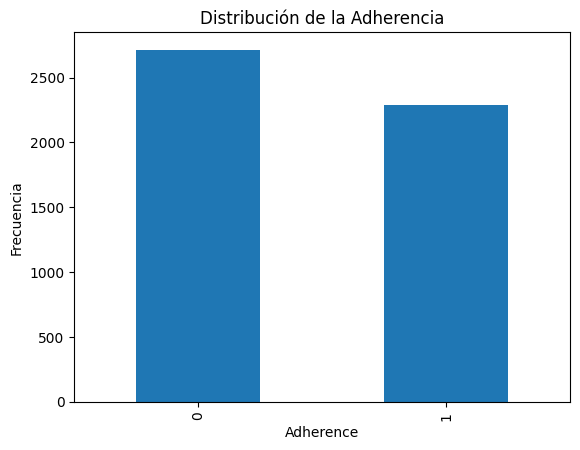

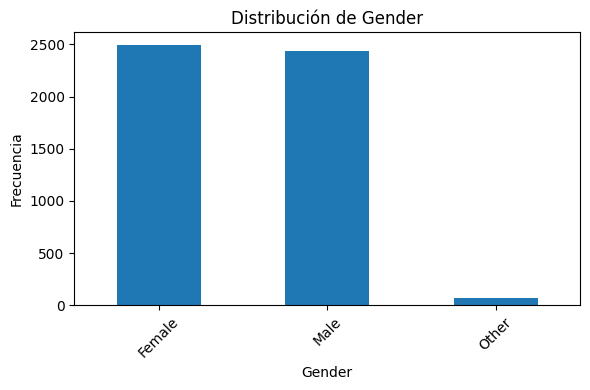

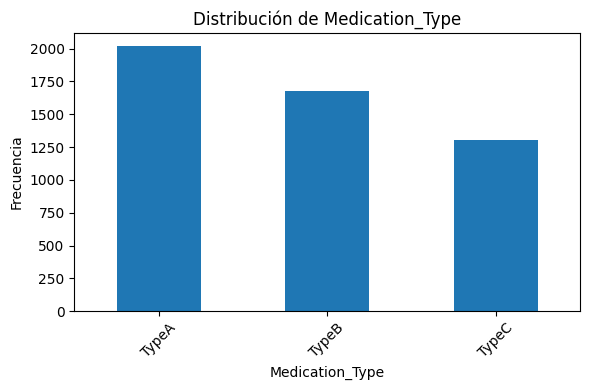

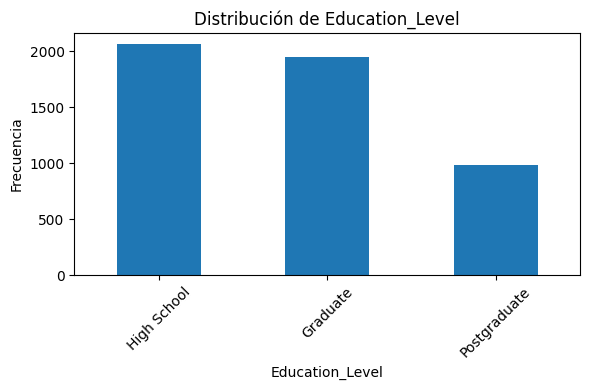

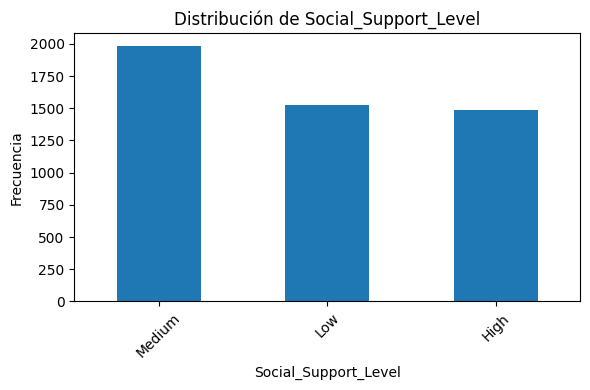

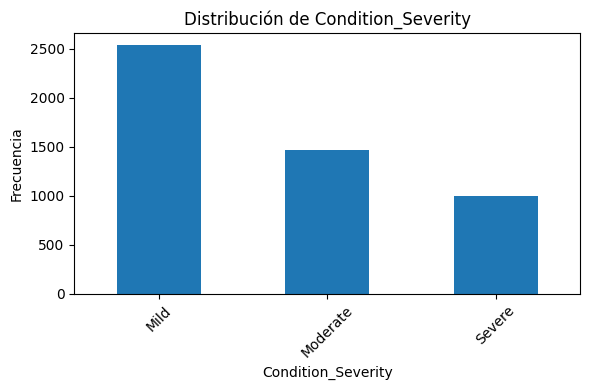

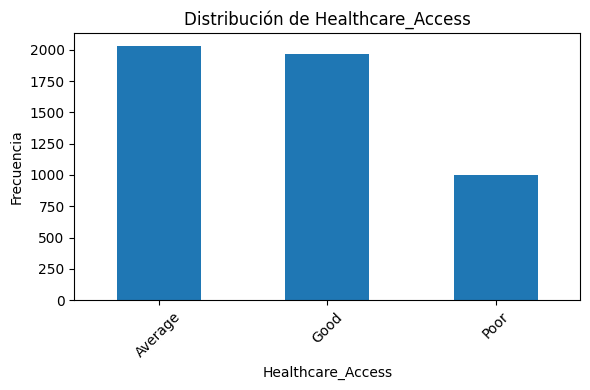

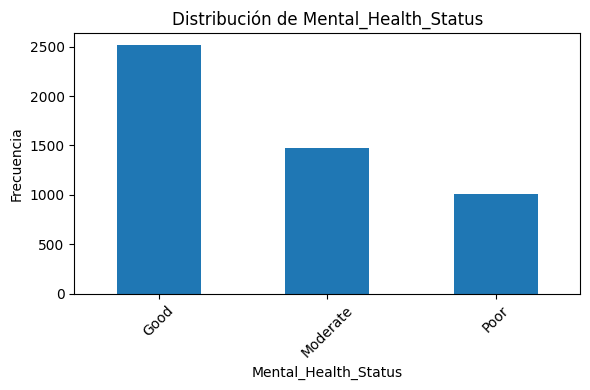

In [ ]:
# =========================================================
# VARIABLES CATEGÓRICAS
# =========================================================
# En este bloque se analiza la distribución de la variable objetivo,
# así como la distribución de las variables categóricas, con el fin
# de comprender mejor la estructura del conjunto de datos.

# Distribución de la variable objetivo
df["Adherence"].value_counts().plot(kind="bar")
plt.title("Distribución de la Adherencia")
plt.xlabel("Adherence")
plt.ylabel("Frecuencia")
plt.show()

# Frecuencia de variables categóricas
for col in categorical_features:
    plt.figure(figsize=(6, 4))
    df[col].value_counts().plot(kind="bar")
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

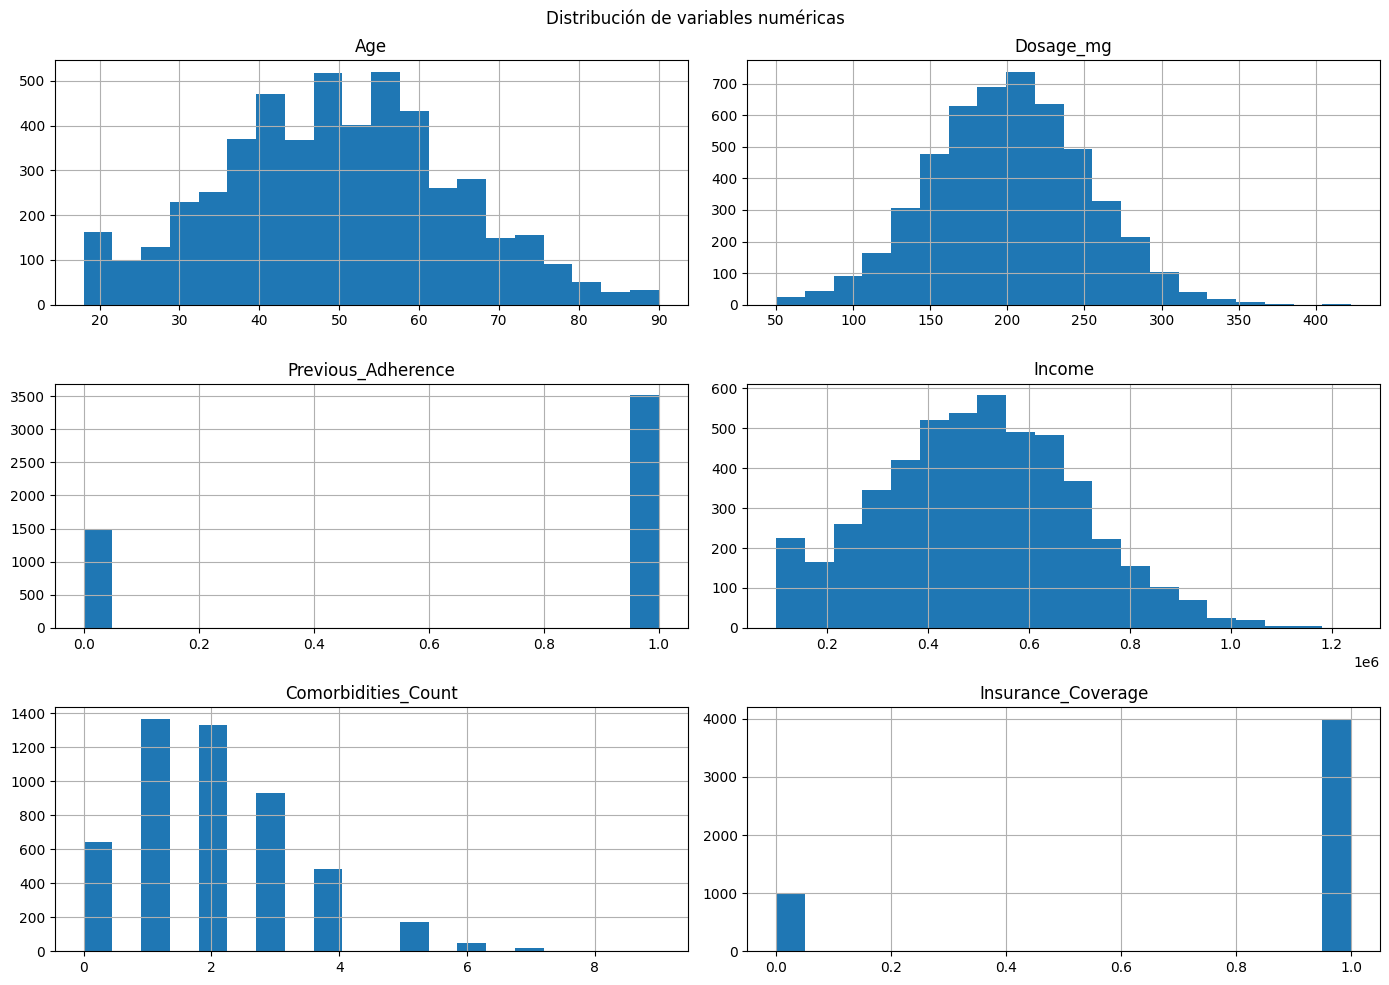

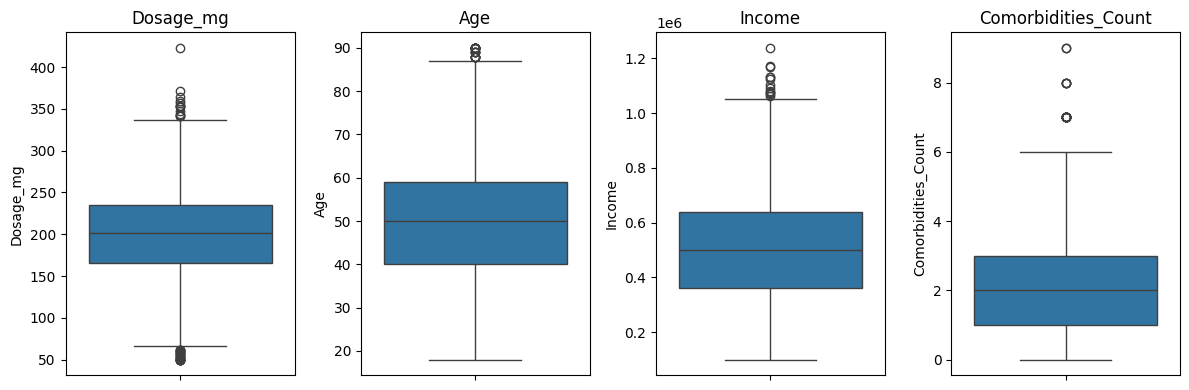

In [ ]:
# =========================================================
# VARIABLES NUMÉRICAS
# =========================================================
# Se realiza una inspección inicial del dataset para:
# - conocer la distribución de las variables numéricas
# - detectar posibles valores atípicos (outliers)

# ---------------------------------------------------------
# Histogramas de variables numéricas
# ---------------------------------------------------------
if numeric_features:
    df[numeric_features].hist(figsize=(14, 10), bins=20)
    plt.suptitle("Distribución de variables numéricas")
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------
# Detección de outliers (variables numéricas)
# ---------------------------------------------------------
num_c = ["Dosage_mg", "Age", "Income", "Comorbidities_Count"]

plt.figure(figsize=(12, 4))

for i, col in enumerate(num_c):
    plt.subplot(1, len(num_c), i+1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

### Análisis de correlación

In [ ]:
# =========================================================
# TRANSFORMACIÓN DEL DATASET PARA EL ANÁLISIS EXPLORATORIO
# =========================================================
# Se transforman las variables categóricas a formato numérico
# con el objetivo de calcular la matriz de correlación de Pearson.

# Este dataset transformado (df_corr) se utiliza únicamente para el EDA,
# No se emplea en el modelado, donde se utilizará un pipeline para evitar
# problemas de data leakage.

df_corr = df.copy()

# ---------------------------------------------------------
# Variables categóricas ordinales (con orden)
# ---------------------------------------------------------

# Education_Level
df_corr['Education_Level'] = df_corr['Education_Level'].map({
    'High School': 0,
    'Graduate': 1,
    'Postgraduate': 2
})

# Social_Support_Level
df_corr['Social_Support_Level'] = df_corr['Social_Support_Level'].map({
    'Low': 0,
    'Medium': 1,
    'High': 2
})

# Condition_Severity
df_corr['Condition_Severity'] = df_corr['Condition_Severity'].map({
    'Mild': 0,
    'Moderate': 1,
    'Severe': 2
})

# Healthcare_Access
df_corr['Healthcare_Access'] = df_corr['Healthcare_Access'].map({
    'Poor': 0,
    'Average': 1,
    'Good': 2
})

# Mental_Health_Status
df_corr['Mental_Health_Status'] = df_corr['Mental_Health_Status'].map({
    'Poor': 0,
    'Moderate': 1,
    'Good': 2
})

# ---------------------------------------------------------
# Variables categóricas nominales (sin orden)
# ---------------------------------------------------------
df_corr = pd.get_dummies(
    df_corr,
    columns=['Gender', 'Medication_Type'],
    drop_first=True,
)

# ---------------------------------------------------------
# Conversión a tipo numérico
# ---------------------------------------------------------
df_corr = df_corr.apply(pd.to_numeric)

# Comprobación del resultado
print(df_corr.info())
df_corr.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   Age                    5000 non-null   int64
 1   Dosage_mg              5000 non-null   int64
 2   Previous_Adherence     5000 non-null   int64
 3   Education_Level        5000 non-null   int64
 4   Income                 5000 non-null   int64
 5   Social_Support_Level   5000 non-null   int64
 6   Condition_Severity     5000 non-null   int64
 7   Comorbidities_Count    5000 non-null   int64
 8   Healthcare_Access      5000 non-null   int64
 9   Mental_Health_Status   5000 non-null   int64
 10  Insurance_Coverage     5000 non-null   int64
 11  Adherence              5000 non-null   int64
 12  Gender_Male            5000 non-null   bool 
 13  Gender_Other           5000 non-null   bool 
 14  Medication_Type_TypeB  5000 non-null   bool 
 15  Medication_Type_TypeC  5000 non-null  

,Age,Dosage_mg,Previous_Adherence,Education_Level,Income,Social_Support_Level,Condition_Severity,Comorbidities_Count,Healthcare_Access,Mental_Health_Status,Insurance_Coverage,Adherence,Gender_Male,Gender_Other,Medication_Type_TypeB,Medication_Type_TypeC
0,57,136,1,0,634934,1,2,3,0,2,1,1,True,False,False,False
1,47,134,1,0,297954,2,1,3,2,2,1,0,True,False,False,False
2,59,89,1,0,789337,2,1,1,2,2,1,1,True,False,False,True
3,72,240,0,2,267352,0,0,2,0,1,1,0,True,False,True,False
4,46,241,1,2,718447,1,0,1,0,2,1,0,True,False,False,False


Para analizar la correlación entre variables, se realiza una transformación temporal del conjunto de datos, convirtiendo todas las variables a formato numérico. Las variables categóricas ordinales se codifican respetando su orden natural, mientras que las variables nominales se transforman mediante codificación one-hot. Este conjunto transformado se utiliza exclusivamente para el análisis exploratorio y no se emplea en el modelado, donde se utiliza un pipeline de preprocesamiento para evitar problemas de fuga de información.

[]

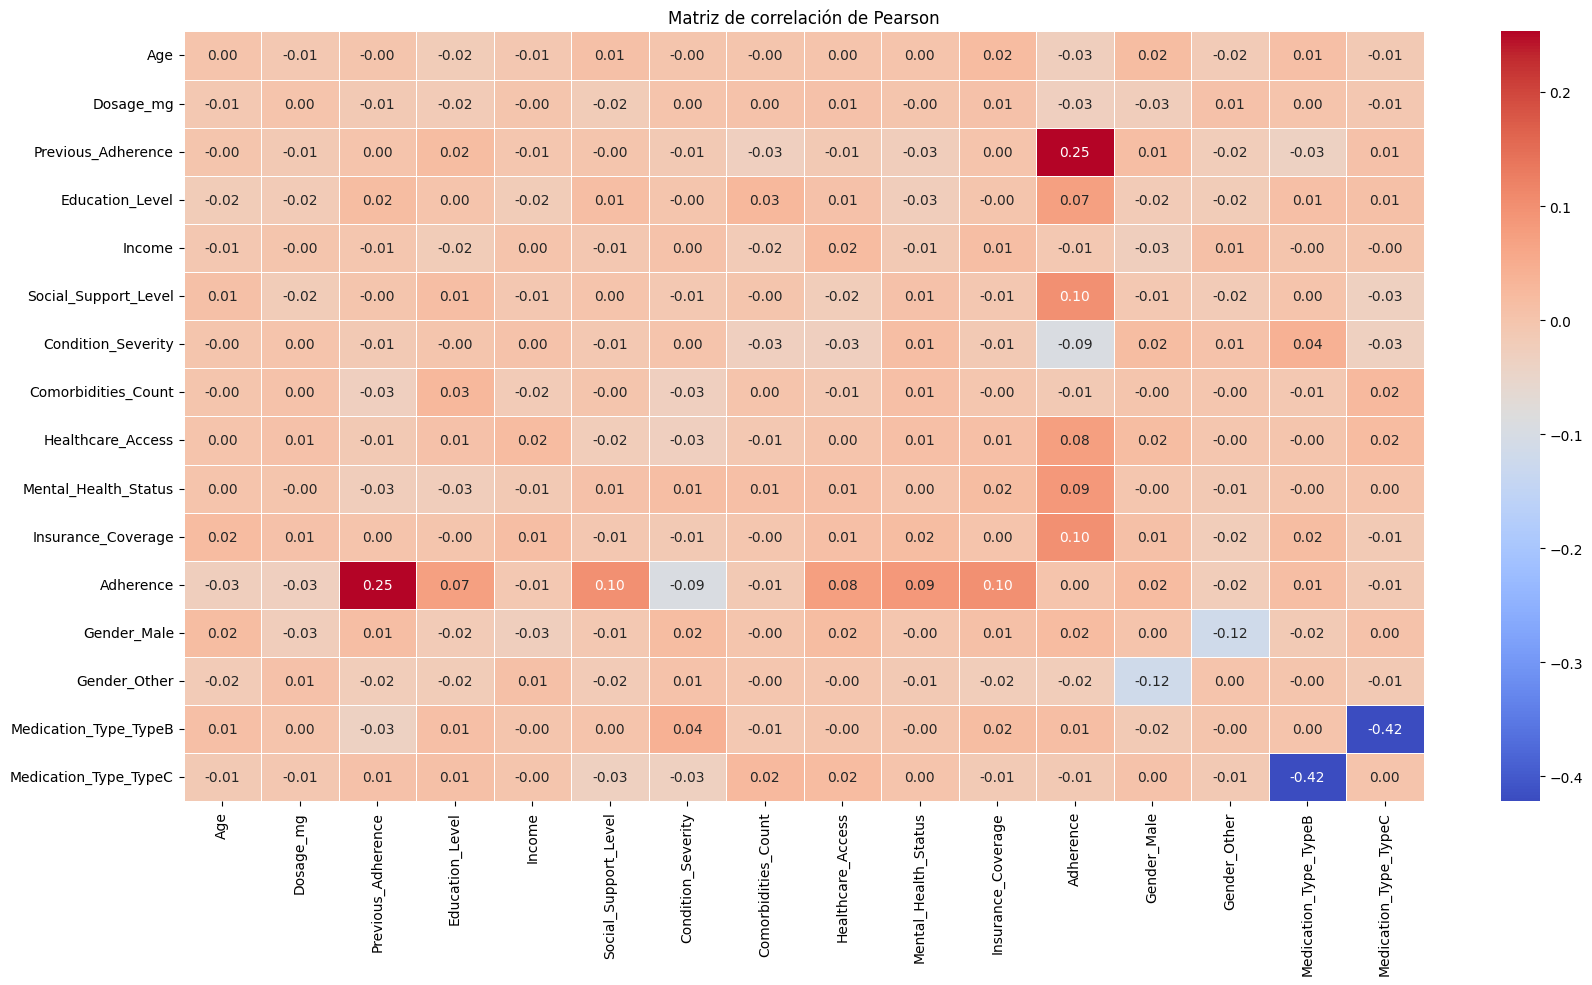

In [ ]:
# =========================================================
# MATRIZ DE CORRELACIÓN DE PEARSON
# =========================================================
# Se calcula la matriz de correlación entre todas las variables
# con el objetivo de identificar posibles relaciones lineales.

# Cálculo de la matriz de correlación
df_pearson_corr = df_corr.corr(numeric_only=True, method='pearson')

# Elimina la autocorrelación (diagonal)
np.fill_diagonal(df_pearson_corr.values, 0)

# Visualización de la matriz
plt.figure(figsize=(20, 10))
sns.heatmap(
    df_pearson_corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)
plt.title('Matriz de correlación de Pearson')
plt.plot()

,Adherence
Previous_Adherence,0.253171
Insurance_Coverage,0.099887
Social_Support_Level,0.098446
Mental_Health_Status,0.086573
Healthcare_Access,0.076338
Education_Level,0.071389
Gender_Male,0.020657
Medication_Type_TypeB,0.013771
Income,-0.009683
Comorbidities_Count,-0.010839


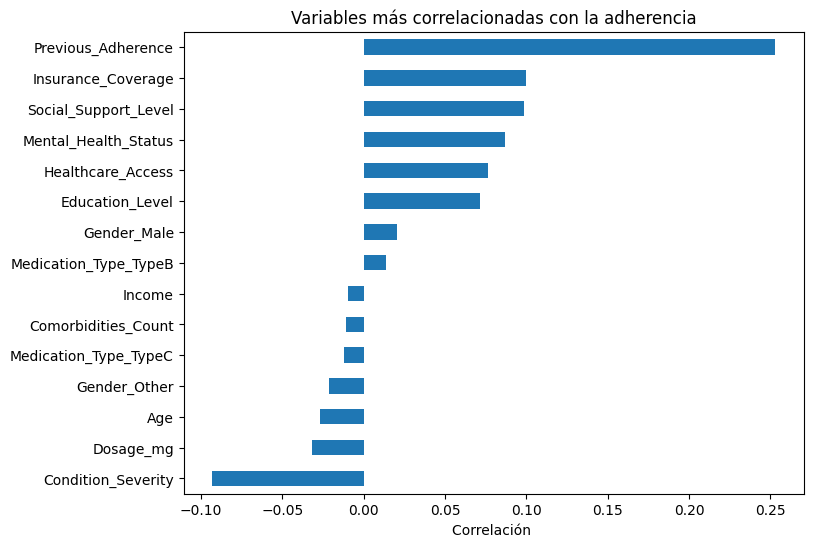

In [ ]:
# =========================================================
# VARIABLES MÁS CORRELACIONADAS CON LA ADHERENCIA
# =========================================================
# Se calcula la correlación de cada variable con la adherencia
# para identificar posibles relaciones lineales
# Se representan las variables con mayor correlación.
# Nota: se utiliza la variable Adherence para facilitar la interpretación.
# En el modelado se emplea Non_Adherence, definida como su complemento,
# por lo que las correlaciones serían equivalentes con signo inverso.

# Matriz de correlación
corr = df_corr.corr()

# Correlación con la variable objetivo
corr_target = corr['Adherence'].sort_values(ascending=False)

display(corr_target.drop("Adherence"))

# ---------------------------------------------------------
# Gráfica de las variables más relevantes
# ---------------------------------------------------------
plt.figure(figsize=(8, 6))
corr_target.drop("Adherence").sort_values().plot(kind="barh")
plt.title("Variables más correlacionadas con la adherencia")
plt.xlabel("Correlación ")
plt.show()

Se analiza la matriz de correlación de Pearson con el objetivo de identificar relaciones lineales entre las variables del conjunto de datos.

Los resultados muestran que, en general, las correlaciones entre las variables son bajas, lo que indica la ausencia de relaciones lineales fuertes. La variable que presenta mayor correlación con la adherencia es la adherencia previa, con un valor aproximado de 0.25. Este resultado resulta coherente desde el punto de vista clínico, ya que el comportamiento pasado del paciente constituye un buen indicador de su comportamiento futuro.

El resto de variables presentan correlaciones débiles con la variable objetivo, con valores generalmente inferiores a 0.1, lo que sugiere que ninguna variable individual explica de forma significativa la adherencia.

Cabe destacar que el análisis de correlación se realiza respecto a la variable de adherencia original, ya que su interpretación resulta más intuitiva. No obstante, en el modelado se utiliza la variable de no adherencia, definida como su complemento. Dado que ambas variables están directamente relacionadas, los resultados de correlación serían equivalentes, presentando únicamente un cambio de signo.

En conjunto, estos resultados indican que la adherencia es un fenómeno complejo que no puede explicarse únicamente mediante relaciones lineales simples, lo que justifica el uso de modelos de aprendizaje automático capaces de capturar patrones más complejos y posibles interacciones entre variables.




## 3. Preprocesamiento de datos

Una vez finalizado el análisis exploratorio, se procede a la preparación del conjunto de datos para su uso en los modelos de aprendizaje automático.

En primer lugar, se definen las variables predictoras (X) y la variable objetivo (y). La variable original de adherencia se transforma para centrar el análisis en la detección de pacientes no adherentes, de modo que la variable objetivo toma el valor 1 para los pacientes no adherentes y 0 para los pacientes adherentes.

A continuación, se realiza la división del conjunto de datos en subconjuntos de entrenamiento, validación y prueba, con el objetivo de evaluar adecuadamente el rendimiento de los modelos y evitar problemas de sobreajuste.

Posteriormente, se define el preprocesamiento que será aplicado durante el entrenamiento de los modelos. Este incluye la normalización de las variables numéricas mediante MinMaxScaler y la codificación de variables categóricas cuando es necesario.

Estas transformaciones se integran dentro del pipeline de modelado, garantizando que se ajusten únicamente con los datos de entrenamiento y se apliquen posteriormente a los conjuntos de validación y prueba, evitando así problemas de fuga de información (data leakage).

In [ ]:
# =========================================================
# DEFINICIÓN DE VARIABLES (X e y)
# =========================================================
# La variable original Adherence toma:
# 1 = paciente adherente
# 0 = paciente no adherente

# Para este estudio interesa detectar a los pacientes no adherentes.
# Por ello, se redefine la variable objetivo:
# 1 = paciente no adherente
# 0 = paciente adherente

df["Non_Adherence"] = 1 - df["Adherence"]

# Variable objetivo
y = df["Non_Adherence"]

# Variables explicativas
# Se eliminan tanto Adherence como Non_Adherence para evitar data leakage.
X = df.drop(columns=["Adherence","Non_Adherence"])

# Comprobaciones
print("Dimensión de X:", X.shape)
print("Dimensión de y:", y.shape)

print(y.value_counts())
print(y.value_counts(normalize=True))

X.head()

Dimensión de X: (5000, 13)
Dimensión de y: (5000,)
Non_Adherence
1    2714
0    2286
Name: count, dtype: int64
Non_Adherence
1    0.5428
0    0.4572
Name: proportion, dtype: float64


,Age,Gender,Medication_Type,Dosage_mg,Previous_Adherence,Education_Level,Income,Social_Support_Level,Condition_Severity,Comorbidities_Count,Healthcare_Access,Mental_Health_Status,Insurance_Coverage
0,57,Male,TypeA,136,1,High School,634934,Medium,Severe,3,Poor,Good,1
1,47,Male,TypeA,134,1,High School,297954,High,Moderate,3,Good,Good,1
2,59,Male,TypeC,89,1,High School,789337,High,Moderate,1,Good,Good,1
3,72,Male,TypeB,240,0,Postgraduate,267352,Low,Mild,2,Poor,Moderate,1
4,46,Male,TypeA,241,1,Postgraduate,718447,Medium,Mild,1,Poor,Good,1


In [ ]:
# =========================================================
# DIVISIÓN DEL CONJUNTO DE DATOS
# =========================================================
# En este bloque se divide el conjunto de datos en tres subconjuntos:
# - Entrenamiento (60%)
# - Validación (20%)
# - Prueba (20%)
#
# Se utiliza estratificación para mantener la proporción de clases
# en todos los subconjuntos, lo cual es especialmente importante
# en problemas de clasificación


# Separamos el conjunto de prueba (20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Dividimos el conjunto restante en entrenamiento (60%) y validación (20%)
# Se divide el 80% restante en:
# - 75% → entrenamiento (0.75 * 0.8 = 0.6)
# - 25% → validación (0.25 * 0.8 = 0.2)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.25,   # 25% de 80% = 20% del total
    random_state=42,
    stratify=y_temp
)

# Verificamos dimensiones
print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (3000, 13) (3000,)
Validation: (1000, 13) (1000,)
Test: (1000, 13) (1000,)


In [ ]:
# =========================================================
# PREPROCESAMIENTO DE VARIABLES
# =========================================================
# En este bloque se define el preprocesamiento de las variables:
# - Variables categóricas nominales → One-Hot Encoding (sin orden)
# - Variables categóricas ordinales → Ordinal Encoding (respetando el orden)
# - Variables numéricas → Normalización (MinMaxScaler)
#
# Todo se integra en un ColumnTransformer para aplicarlo de forma consistente


# ---------------------------------------------------------
# Variables categóricas nominales (sin orden)
# ---------------------------------------------------------
categ_nom = ["Gender", "Medication_Type"]

# ---------------------------------------------------------
# Variables categóricas ordinales (con orden)
# ---------------------------------------------------------
categ_ord = [
    "Education_Level",
    "Social_Support_Level",
    "Condition_Severity",
    "Healthcare_Access",
    "Mental_Health_Status"
]

# ---------------------------------------------------------
# Variables numéricas
# ---------------------------------------------------------
# se seleccionan automáticamente aquellas que no han sido definidas previamente
num_cols = [
    col for col in X.columns
    if col not in categ_nom + categ_ord
]

# Codificación ordinal (respetando el orden)
ordinal_transformer = OrdinalEncoder(categories=[
    ["High School", "Graduate", "Postgraduate"],
    ["Low", "Medium", "High"],
    ["Mild", "Moderate", "Severe"],
    ["Poor", "Average", "Good"],
    ["Poor", "Moderate", "Good"]
])


# ---------------------------------------------------------
# ColumnTransformer
# ---------------------------------------------------------
preprocessor = ColumnTransformer([
    ("ord", ordinal_transformer, categ_ord),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first"), categ_nom),
    ("scale", MinMaxScaler(), num_cols)
])

Para el preprocesamiento de los datos se emplea un enfoque diferenciado en función del tipo de variable. Las variables categóricas ordinales se codifican respetando su orden natural mediante un OrdinalEncoder, mientras que las variables categóricas nominales se transforman mediante codificación one-hot. En este caso, se elimina una de las categorías de referencia (drop="first") con el objetivo de evitar problemas de multicolinealidad en los modelos lineales.

Por su parte, las variables numéricas se escalan utilizando MinMaxScaler, con el objetivo de situarlas en una escala comparable.

Este conjunto de transformaciones se integra mediante un ColumnTransformer, lo que permite aplicar de forma coherente el preprocesamiento dentro de los pipelines de modelado. De este modo, dichas transformaciones se ajustan exclusivamente con los datos de entrenamiento y se aplican posteriormente a los conjuntos de validación y prueba, evitando así problemas de fuga de información (data leakage).

## 4. Aprendizaje Supervisado: predicción de adherencia

En esta sección se abordan los modelos de aprendizaje supervisado utilizados para predecir la probabilidad de que un paciente no siga adecuadamente el tratamiento farmacológico prescrito. Para ello, se define como variable objetivo la no adherencia, donde el valor 1 representa a los pacientes no adherentes y el valor 0 a los pacientes adherentes.

## 4.1. Ajuste y comparación de modelos supervisados

Se seleccionan distintos algoritmos representativos de diferentes enfoques dentro del aprendizaje automático, con el objetivo de comparar su rendimiento en el problema planteado:

- Regresión logística, como modelo lineal de referencia.
- Random Forest, basado en la combinación de múltiples árboles de decisión mediante técnicas de *bagging*.
- XGBoost, como método de *gradient boosting* orientado a mejorar el rendimiento predictivo mediante la construcción secuencial de árboles.
- Red neuronal multicapa (MLP), como modelo capaz de capturar relaciones no lineales complejas.

Esta selección permite comparar modelos con distinto nivel de complejidad, capacidad de generalización e interpretabilidad, facilitando la identificación del enfoque más adecuado para el problema estudiado.

In [ ]:
# =========================================================
# DEFINICIÓN DE LOS MODELOS SUPERVISADOS
# =========================================================
# En este bloque se definen los modelos de clasificación que se van a comparar
# Los algoritmos de Machine Learning que se incluyen son:
# - Regresión logística (modelo lineal)
# - Random Forest (modelo basado en árboles)
# - MLP (red neuronal)
# - XGBoost (boosting), si está disponible en el entorno
#
# Para cada modelo se establecen hiperparámetros iniciales razonables
# con el objetivo de realizar una primera comparación en condiciones mas o menos homogéneas

# ---------------------------------------------------------
# Definición de los modelos
# ---------------------------------------------------------
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,                # Número máximo de iteraciones
        solver="lbfgs",               # Optimizador, estable para la clasificación binaria
        class_weight="balanced",      # Ajusta el peso de las clases
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=600,             # Número total de árboles que tendrá el bosque
        max_depth=12,                 # Profundidad máxima de cada árbol, la limitamos para evitar el sobreajuste
        min_samples_split=5,          # Número mínimo de muestras necesarias para dividir un nodo interno
        min_samples_leaf=2,           # Número mínimo de muestras necesarias en una hoja
        max_features="sqrt",          # Número máximo de características a considerar al dividir un nodo
        class_weight="balanced",      # Ajusta el peso de las clases
        n_jobs=-1,                    # Utiliza todos los núcleos disponibles del procesador
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=500,               # Número total de árboles
        max_depth=4,                    # Profundidad máxima de cada árbol
        learning_rate=0.03,             # Estrategia de ajuste de la tasa de aprendizaje
        subsample=0.8,                  # Proporción de muestras usada en cada árbol (introduce aleatoriedad, ayuda a evitar el sobreajuste)
        colsample_bytree=0.8,           # Proporción de variables usadas en cada árbol (ayuda a evitar el sobreajuste)
        min_child_weight=3,             # Peso mínimo para crear un nodo hijo
        reg_alpha=0.1,                  # Regularización L1
        reg_lambda=1.5,                 # Regularización L2
        eval_metric="logloss",          # Métrica interna usada durante el entrenamiento (habitual en clasificación binaria)
        random_state=42
    ),

    "MLP": MLPClassifier(
        hidden_layer_sizes=(64, 32),        # Arquitectura de la Red Neuronal (2 capas ocultas)
        activation="relu",                  # Función de activación utilizada en las neuronas ocultas
        solver="adam",                      # Optimizador estándar
        alpha=0.001,                        # Parámetro de regularización L2 (ayuda a evitar el sobreajuste)
        learning_rate="adaptive",           # Estrategia de ajuste de la tasa de aprendizaje
        learning_rate_init=0.001,           # Tasa de aprendizaje inicial
        max_iter=1500,                      # Número máximo de iteraciones de entrenamiento
        early_stopping=True,                # Detiene el entrenamiento automáticamente si el modelo deja de mejorar
        validation_fraction=0.1,            # Proporción de datos de validación
        n_iter_no_change=20,                # Número de iteraciones sin mejora antes de detener el entrenamiento
        random_state=42
    )

  }

print("Modelos definidos:", list(models.keys()))


Modelos definidos: ['Logistic Regression', 'Random Forest', 'XGBoost', 'MLP']


Se definieron distintos modelos supervisados representativos de varios enfoques de clasificación: un modelo lineal (regresión logística), un modelo basado en árboles (Random Forest), una red neuronal multicapa (MLP) y un modelo de boosting (XGBoost). Para cada uno de ellos se establecieron hiperparámetros iniciales razonables, con el objetivo de realizar una primera comparación homogénea de su rendimiento.

In [ ]:
# =========================================================
# DEFINICIÓN DEL PIPELINE
# =========================================================
# Este bloque construye pipelines para cada modelo
# Cada pipeline incluye:
# - el preprocesamiento de los datos (ColumnTransformer)
# - los modelos: 'Logistic Regression', 'Random Forest', 'MLP', 'XGBoost'
#
# Esto permite:
# - aplicar las mismas transformaciones a todos los modelos
# - evitar data leakage
# - mantener un flujo de trabajo limpio y reproducible

# Diccionario para almacenar los pipelines
pipelines = {}

# Creación de un pipeline para cada modelo ya definido
for name, model in models.items():
  pipelines[name] = Pipeline([
    ("preprocessing", preprocessor),      # transformación de los datos
    ("model", model)                      # modelos de ML
  ])

print("Pipelines creados:", list(pipelines.keys()))

Pipelines creados: ['Logistic Regression', 'Random Forest', 'XGBoost', 'MLP']


### Metodología de entrenamiento y evaluación

Para evaluar el rendimiento de los modelos, el conjunto de datos se divide en tres subconjuntos: entrenamiento, validación y prueba. Esta estrategia permite evitar problemas de sobreajuste y evaluar adecuadamente la capacidad de generalización de los modelos.

En una primera fase, los modelos de regresión logística, Random Forest, XGBoost y MLP se entrenan utilizando el conjunto de entrenamiento y se evalúan sobre el conjunto de validación, con el objetivo de comparar su rendimiento bajo las mismas condiciones.

Las métricas empleadas para la evaluación son:

- Accuracy: proporción de predicciones correctas sobre el total de observaciones.
- Precision: proporción de pacientes predichos como no adherentes que realmente lo son.
- Recall: proporción de pacientes no adherentes correctamente identificados por el modelo.
- F1-score: medida que combina precisión y recall, especialmente relevante en problemas con posible desbalanceo de clases.
- ROC-AUC: métrica que evalúa la capacidad del modelo para discriminar entre pacientes adherentes y no adherentes.

Estas métricas permiten obtener una visión completa del comportamiento de los modelos. En particular, el recall resulta especialmente relevante en este contexto, ya que permite identificar correctamente a los pacientes no adherentes, lo cual puede ser crítico desde el punto de vista clínico.

In [ ]:
# =========================================================
# ENTRENAMIENTO DE LOS MODELOS
# =========================================================
# En este bloque se entrenan todos los pipelines ya definidos,
# para ello utilizamos el conjunto de entrenamiento.

# También se mide el tiempo de entrenamiento de cada modelo,
# para comparar los costes computacionales.

import time

# Diccionario para almacenar los pipelines entrenados
trained_pipelines = {}

for name, pipe in pipelines.items():
    # Medimos el tiempo de entrenamiento
    start_time = time.time()

    print(f"Entrenando modelo: {name}")
    # Entrenamos el modelo
    pipe.fit(X_train, y_train)

    end_time = time.time()
    print(f"Tiempo: {round(end_time - start_time, 2)} segundos\n")

    # Guardamos el modelo entrenado
    trained_pipelines[name] = pipe

print("Modelos entrenados correctamente.")

Entrenando modelo: Logistic Regression
Tiempo: 0.15 segundos

Entrenando modelo: Random Forest
Tiempo: 6.36 segundos

Entrenando modelo: XGBoost
Tiempo: 4.65 segundos

Entrenando modelo: MLP
Tiempo: 1.35 segundos

Modelos entrenados correctamente.


In [ ]:
# =========================================================
# COMPARACIÓN DE MODELOS CON EL CONJUNTO DE VALIDACIÓN
# =========================================================
# En este bloque se evalúan todos los modelos entrenados
# utilizando el conjunto de validación.
# Se calculan las métricas principales para cada modelo.

val_results = []

# Recorremos todos los modelos entrenados
for name, pipe in trained_pipelines.items():

    # Predicciones de clase con el threshold por defecto (0.5)
    y_pred = pipe.predict(X_val)

    # Probabilidades (necesarias para ROC-AUC)
    if hasattr(pipe, "predict_proba"):
        y_prob = pipe.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_prob)
    else:
        y_prob = None
        auc = None

    # Guardamos resultados
    val_results.append({
        "Modelo": name,
        "Accuracy": accuracy_score(y_val, y_pred),
        "Precision": precision_score(y_val, y_pred, zero_division=0),
        "Recall": recall_score(y_val, y_pred, zero_division=0),
        "F1-score": f1_score(y_val, y_pred, zero_division=0),
        "ROC-AUC": auc
    })

# Convertimos a DataFrame
val_results_df = pd.DataFrame(val_results)

# Ordenamos por F1-score
val_results_df = val_results_df.sort_values(by="F1-score", ascending=False)

# Mostramos resultados
display(val_results_df.round(3))

,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC
2,XGBoost,0.628,0.647,0.694,0.670,0.686
3,MLP,0.611,0.622,0.724,0.669,0.668
1,Random Forest,0.635,0.669,0.650,0.659,0.694
0,Logistic Regression,0.645,0.690,0.628,0.658,0.703


En términos generales, los modelos muestran un rendimiento similar en cuanto a accuracy y ROC-AUC, con valores comprendidos aproximadamente entre 0.61 y 0.65 para accuracy y entre 0.66 y 0.70 para ROC-AUC. Esto indica que todos los modelos presentan una capacidad moderada para discriminar entre pacientes adherentes y no adherentes.

El modelo de regresión logística obtiene el mejor resultado en accuracy (0.645), precision (0.690) y ROC-AUC (0.703), lo que indica una alta proporción de predicciones positivas correctas y una buena capacidad global de discriminación entre clases.

Por otro lado, la red neuronal (MLP) presenta el mayor valor de recall (0.724), lo que sugiere una mejor capacidad para identificar correctamente a los pacientes no adherentes, aunque a costa de una menor precisión.

El modelo XGBoost destaca por obtener el mayor valor de F1-score (0.670), lo que indica un mejor equilibrio entre precision y recall, siendo un modelo competitivo en términos globales.

El modelo Random Forest presenta un rendimiento equilibrado, con valores intermedios en todas las métricas, destacando especialmente por su estabilidad, aunque sin liderar en ninguna métrica concreta.

En cuanto al tiempo de entrenamiento, se observan diferencias significativas entre los modelos. La regresión logística presenta el menor tiempo de entrenamiento, lo que la convierte en una opción eficiente desde el punto de vista computacional. Por el contrario, Random Forest requiere un mayor tiempo de entrenamiento debido a la construcción de múltiples árboles de decisión.

Los modelos XGBoost y MLP presentan tiempos intermedios, manteniendo un equilibrio entre coste computacional y rendimiento. Estos resultados ponen de manifiesto la importancia de considerar no solo el rendimiento predictivo, sino también la eficiencia computacional en la selección del modelo.

En conjunto, los resultados reflejan que no existe un modelo claramente superior en todas las métricas, lo que evidencia la complejidad del problema y la necesidad de considerar distintos criterios en la selección del modelo final.

Cabe destacar que la elección del modelo óptimo no depende únicamente de una métrica, sino del contexto del problema. En este caso, dado que la identificación de pacientes con baja adherencia resulta especialmente relevante desde el punto de vista clínico, métricas como el recall adquieren mayor importancia.

## 4.2. Ajuste del modelo seleccionado

### Elección del modelo final

A partir de los resultados obtenidos en el conjunto de validación, se procede a la selección del modelo más adecuado para el problema de predicción de la no adherencia al tratamiento.

Tal y como se ha observado, ninguno de los modelos evaluados destaca de forma clara en todas las métricas consideradas, lo que pone de manifiesto la complejidad del problema. Por este motivo, la selección del modelo final no se basa únicamente en una métrica concreta, sino en un análisis conjunto de su rendimiento.

El modelo de regresión logística obtiene los mejores resultados en términos de accuracy, precision y ROC-AUC, lo que indica una alta proporción de predicciones correctas y una buena capacidad de discriminación global entre pacientes adherentes y no adherentes. Por otro lado, la red neuronal (MLP) presenta el mayor valor de recall, lo que sugiere una mayor capacidad para identificar correctamente a los pacientes no adherentes, aunque a costa de una menor precisión.

Por su parte, el modelo XGBoost destaca por obtener el mejor resultado en términos de F1-score, lo que indica un mejor equilibrio entre precision y recall. Además, presenta un rendimiento competitivo en el resto de métricas, lo que refleja una adecuada capacidad de generalización.

En base a estos resultados, se selecciona el modelo XGBoost como modelo final. Esta decisión no se fundamenta únicamente en su rendimiento inicial, sino también en su capacidad para ser optimizado mediante el ajuste de hiperparámetros y la modificación del umbral de decisión (threshold). Estas características permiten adaptar el modelo a las necesidades específicas del problema, especialmente en contextos clínicos donde la correcta identificación de pacientes no adherentes resulta prioritaria.

Este modelo será utilizado en las fases posteriores del análisis, incluyendo el ajuste de hiperparámetros y la evaluación final sobre el conjunto de prueba.

### Ajuste del modelo seleccionado

Una vez seleccionado el modelo XGBoost como el más adecuado para el problema planteado, se procede al ajuste de sus hiperparámetros con el objetivo de optimizar su rendimiento.

Este proceso se lleva a cabo mediante la técnica de RandomizedSearchCV, que permite explorar de forma eficiente distintas combinaciones de parámetros a partir de una distribución predefinida. A diferencia de métodos exhaustivos como GridSearch, esta aproximación evalúa un número limitado de configuraciones seleccionadas aleatoriamente, reduciendo el coste computacional sin comprometer significativamente la calidad de la optimización.

En este caso, se analizan 30 combinaciones diferentes de hiperparámetros (n_iter = 30), utilizando validación cruzada con 5 particiones (cv = 5), lo que permite obtener una estimación más robusta del rendimiento del modelo y evitar depender de una única partición de los datos.

Entre los hiperparámetros considerados se incluyen el número de estimadores (n_estimators), la profundidad máxima de los árboles (max_depth), la tasa de aprendizaje (learning_rate), así como otros parámetros relacionados con la regularización y el muestreo de datos, todos ellos relevantes para el comportamiento del modelo XGBoost.

La métrica empleada para la optimización es el F1-score, dado que proporciona un equilibrio entre precision y recall, lo que resulta especialmente adecuado en este problema, donde es importante detectar correctamente a los pacientes no adherentes sin generar un número excesivo de falsos positivos.

Este proceso se ejecuta en paralelo utilizando todos los núcleos disponibles (n_jobs = -1), lo que permite reducir significativamente el tiempo de cómputo.

El ajuste se realiza utilizando exclusivamente el conjunto de entrenamiento, evitando así la utilización de información procedente del conjunto de validación o del conjunto de prueba durante el proceso de optimización, lo que garantiza una evaluación adecuada de la capacidad de generalización del modelo.

Como resultado, se obtiene una configuración optimizada del modelo XGBoost que mejora su rendimiento predictivo y permite un mejor equilibrio entre complejidad y capacidad de generalización. Este modelo ajustado será utilizado posteriormente en la evaluación final sobre el conjunto de prueba.

In [ ]:
# =========================================================
# BÚSQUEDA ALEATORIA DE HIPERPARÁMETROS (XGBOOST)
# =========================================================
# En este bloque se ajusta el modelo XGBoost mediante RandomizedSearchCV
# con el objetivo de encontrar una combinación de hiperparámetros
# que mejore el rendimiento del modelo en términos de F1-score.


# ---------------------------------------------------------
# Definición del pipeline
# ---------------------------------------------------------
# El pipeline integra:
# - el preprocesamiento de los datos
# - el modelo XGBoost
#
# Esto garantiza que todas las transformaciones se apliquen
# correctamente dentro de cada partición de validación cruzada,
# evitando problemas de data leakage.

xgb_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ))
])

# ---------------------------------------------------------
# Búsqueda de hiperparámetros
# ---------------------------------------------------------
# Se definen los rangos de valores que se explorarán de forma aleatoria.
# Cada parámetro influye en la complejidad, regularización y capacidad
# de generalización del modelo.

param_dist = {
    "model__n_estimators": randint(200, 800),          # número de árboles
    "model__max_depth": randint(2, 6),                 # profundidad máxima de cada árbol
    "model__learning_rate": uniform(0.01, 0.1),        # tasa de aprendizaje
    "model__subsample": uniform(0.7, 0.3),             # proporción de muestras usadas por árbol
    "model__colsample_bytree": uniform(0.7, 0.3),      # proporción de variables usadas por árbol
    "model__min_child_weight": randint(1, 6),          # peso mínimo en los nodos hoja
    "model__gamma": uniform(0, 0.3),                   # reducción mínima de pérdida para dividir nodos
    "model__reg_alpha": uniform(0, 1),                 # regularización L1
    "model__reg_lambda": uniform(0.5, 2)               # regularización L2
}

# ---------------------------------------------------------
# Configuración de la búsqueda aleatoria
# ---------------------------------------------------------
# RandomizedSearchCV permite probar un número limitado de combinaciones
# de hiperparámetros de forma eficiente, sin explorar todas las posibles.
#
# Se utiliza:
# - validación cruzada de 5 particiones
# - F1-score como métrica principal
# - paralelización para acelerar el proceso

xgb_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_dist,
    n_iter=30,             # número de combinaciones aleatorias a evaluar
    scoring="f1",          # métrica de evaluación
    cv=5,                  # validación cruzada con 5 particiones
    verbose=1,             # mostrar progreso
    n_jobs=-1,             # usar todos los núcleos disponibles
    random_state=42
)

# ---------------------------------------------------------
# Entrenamiento de la búsqueda
# ---------------------------------------------------------
# Se ajusta la búsqueda únicamente con el conjunto de entrenamiento.
# El conjunto de validación queda reservado para evaluar el modelo
# ajustado posteriormente.

xgb_search.fit(X_train, y_train)

# ---------------------------------------------------------
# Resultados del ajuste
# ---------------------------------------------------------
# Se muestran:
# - los mejores hiperparámetros encontrados
# - el mejor F1-score medio obtenido en validación cruzada

print("Mejores parámetros encontrados para XGBoost:")
print(xgb_search.best_params_)

print("\nMejor F1-score medio en validación cruzada:")
print(xgb_search.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Mejores parámetros encontrados para XGBoost:
{'model__colsample_bytree': np.float64(0.8900589132282684), 'model__gamma': np.float64(0.16073240522242754), 'model__learning_rate': np.float64(0.01902897700544083), 'model__max_depth': 2, 'model__min_child_weight': 1, 'model__n_estimators': 323, 'model__reg_alpha': np.float64(0.5081987767407187), 'model__reg_lambda': np.float64(1.8916256135817637), 'model__subsample': np.float64(0.9575076414441159)}

Mejor F1-score medio en validación cruzada:
0.6680920485435353


## 4.3. Optimización del umbral de decisión

En los modelos de clasificación binaria, la asignación final de clases suele realizarse utilizando un umbral de decisión por defecto de 0.5 sobre las probabilidades predichas. Sin embargo, este valor no siempre es el más adecuado, especialmente en problemas donde el coste de los errores no es simétrico.

En el contexto de la predicción de la no adherencia a tratamientos farmacológicos, resulta especialmente relevante identificar correctamente a los pacientes no adherentes. Por este motivo, se analiza el impacto de distintos valores del umbral de decisión sobre las métricas de evaluación, con el objetivo de encontrar un equilibrio más adecuado entre precision y recall.

Para ello, se evalúan diferentes valores del umbral utilizando el conjunto de validación, seleccionando aquel que maximiza el F1-score. Este proceso se basa en las probabilidades predichas por el modelo, transformándolas en clases en función de distintos valores del umbral.

In [ ]:
# =========================================================
# AJUSTE DE XGBOOST Y OPTIMIZACIÓN DEL THRESHOLD
# =========================================================
# Tomamos el mejor estimador obtenido en la optimización de XGBoost.
best_xgb = xgb_search.best_estimator_

# =========================================================
# VALIDACIÓN CRUZADA
# =========================================================
# Calculamos el F1 medio mediante validación cruzada
# usando solo el conjunto de entrenamiento.


cv_scores = cross_val_score(
    best_xgb,
    X_train,
    y_train,
    cv=5,
    scoring="f1"
)

print("F1 CV medio:", cv_scores.mean())
print("Desviación estándar:", cv_scores.std())

# =========================================================
# PREDECIMOS EN VALIDACIÓN
# =========================================================
# Obtenemos:
# - las predicciones por defecto del modelo (threshold = 0.5)
# - las probabilidades para la clase positiva (paciente no adherente = 1)
y_val_pred_default = best_xgb.predict(X_val)
y_val_prob = best_xgb.predict_proba(X_val)[:, 1]

# =========================================================
# BÚSQUEDA DEL THRESHOLD ÓPTIMO
# =========================================================
# Probamos distintos thresholds y elegimos el que maximiza el F1-score.

thresholds = np.arange(0.10, 0.90, 0.01)
f1_scores = []

for t in thresholds:
    y_pred_temp = (y_val_prob >= t).astype(int)
    f1_scores.append(f1_score(y_val, y_pred_temp))

best_threshold = thresholds[np.argmax(f1_scores)]
best_f1 = max(f1_scores)

print("Best threshold:", best_threshold)
print("Best F1:", best_f1)

# =========================================================
# PREDICCIÓN CON EL MEJOR THRESHOLD
# =========================================================
# Esta es la predicción que debes usar para accuracy, precision, recall y F1
# si quieres evaluar el modelo con el threshold ajustado.
y_val_pred_thr = (y_val_prob >= best_threshold).astype(int)

F1 CV medio: 0.6680920485435353
Desviación estándar: 0.011810874033493509
Best threshold: 0.4199999999999998
Best F1: 0.7243975903614458


Como resultado de este análisis, se obtiene un umbral óptimo de aproximadamente 0.42, que permite mejorar el rendimiento del modelo en comparación con el valor por defecto. En concreto, el F1-score alcanza un valor de 0.724, lo que supone una mejora significativa respecto al obtenido con el umbral estándar.

Este resultado indica que el modelo logra un mejor equilibrio entre precision y recall, aumentando su capacidad para identificar correctamente a los pacientes no adherentes sin degradar excesivamente la precisión de las predicciones.

Además, el modelo presenta un rendimiento estable durante el proceso de validación cruzada, con un F1-score medio de 0.668 y una baja desviación estándar (0.012), lo que sugiere una buena capacidad de generalización y consistencia en distintos subconjuntos de datos.

En términos prácticos, la reducción del umbral respecto al valor por defecto implica una mayor sensibilidad del modelo hacia la detección de pacientes no adherentes. Aunque esto puede conllevar un incremento en el número de falsos positivos, en el contexto sanitario resulta preferible priorizar la detección de pacientes en riesgo, ya que estos pueden ser objeto de seguimiento o intervención posterior.

En consecuencia, la optimización del umbral de decisión constituye una etapa clave en el proceso de modelado, permitiendo adaptar el comportamiento del modelo a las necesidades específicas del problema y mejorar su aplicabilidad en un entorno clínico.

=== MÉTRICAS CON THRESHOLD POR DEFECTO (0.5) ===
Accuracy: 0.648
Precision: 0.6589018302828619
Recall: 0.7292817679558011
F1-score: 0.6923076923076923
ROC-AUC: 0.7043332487074403

=== MÉTRICAS CON THRESHOLD AJUSTADO ===
Accuracy: 0.634
Precision: 0.6127388535031847
Recall: 0.8858195211786372
F1-score: 0.7243975903614458
ROC-AUC: 0.7043332487074403


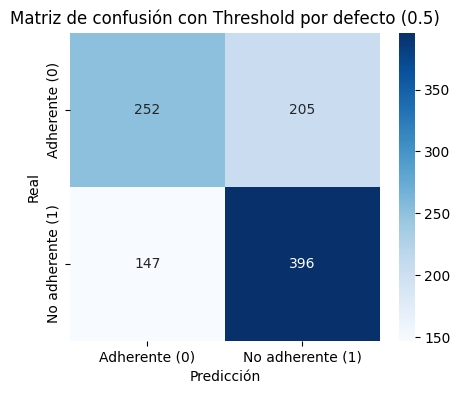

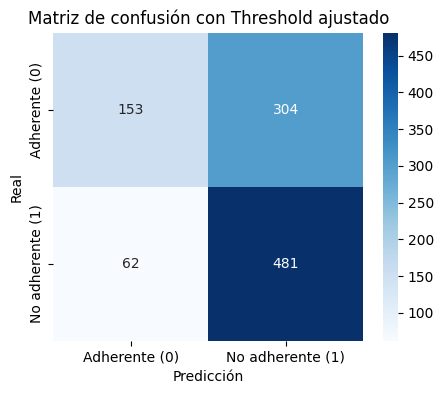

In [ ]:
# =========================================================
# COMPARACIÓN DE MÉTRICAS
# =========================================================

print("=== MÉTRICAS CON THRESHOLD POR DEFECTO (0.5) ===")
print("Accuracy:", accuracy_score(y_val, y_val_pred_default))
print("Precision:", precision_score(y_val, y_val_pred_default, zero_division=0))
print("Recall:", recall_score(y_val, y_val_pred_default, zero_division=0))
print("F1-score:", f1_score(y_val, y_val_pred_default, zero_division=0))
print("ROC-AUC:", roc_auc_score(y_val, y_val_prob)) # NO usa threshold

print("")

print("=== MÉTRICAS CON THRESHOLD AJUSTADO ===")
print("Accuracy:", accuracy_score(y_val, y_val_pred_thr))
print("Precision:", precision_score(y_val, y_val_pred_thr, zero_division=0))
print("Recall:", recall_score(y_val, y_val_pred_thr, zero_division=0))
print("F1-score:", f1_score(y_val, y_val_pred_thr, zero_division=0))
print("ROC-AUC:", roc_auc_score(y_val, y_val_prob))  # NO usa threshold

# =========================================================
# MATRIZ DE CONFUSIÓN
# =========================================================
labels = ["Adherente (0)", "No adherente (1)"]

# THRESHOLD POR DEFECTO (0.5)

cm = confusion_matrix(y_val, y_val_pred_default)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels = labels, yticklabels= labels)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión con Threshold por defecto (0.5)")
plt.show()

# THRESHOLD AJUSTADO

cm = confusion_matrix(y_val, y_val_pred_thr)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión con Threshold ajustado")
plt.show()

Para analizar el rendimiento del modelo XGBoost, se comparan los resultados obtenidos utilizando el umbral de decisión por defecto (0.5) y un umbral ajustado, tanto mediante métricas como a través de las matrices de confusión.

Con el umbral por defecto, el modelo presenta un accuracy de 0.648 y un F1-score de 0.692, con valores relativamente equilibrados de precision (0.659) y recall (0.729). La matriz de confusión muestra un número moderado de falsos positivos (205) y un número considerable de falsos negativos (147), lo que indica que el modelo no identifica correctamente a una parte relevante de los pacientes no adherentes.

Al aplicar el umbral ajustado (≈ 0.42), se observa un cambio significativo en el comportamiento del modelo. El recall aumenta notablemente hasta 0.886, lo que implica que la gran mayoría de los pacientes no adherentes son correctamente identificados (481 verdaderos positivos frente a solo 62 falsos negativos). Sin embargo, este incremento se produce a costa de un aumento considerable de los falsos positivos (304), lo que reduce la precision (0.613) y el accuracy (0.634).

El F1-score mejora hasta 0.724, lo que indica un mejor equilibrio global entre precision y recall en comparación con el umbral por defecto.

Cabe destacar que la métrica ROC-AUC se mantiene constante (0.704), ya que no depende del umbral de decisión. Esto indica que la capacidad discriminativa del modelo no varía, sino únicamente el criterio utilizado para asignar las clases.

En conjunto, las matrices de confusión reflejan claramente el trade-off existente entre precision y recall. Mientras que el umbral por defecto prioriza una menor tasa de falsos positivos, el umbral ajustado prioriza la detección de pacientes no adherentes, reduciendo de forma significativa los falsos negativos.

Dado que en este contexto resulta especialmente relevante identificar a los pacientes con baja adherencia, el uso de un umbral ajustado se considera más adecuado, ya que permite maximizar la detección de estos casos, incluso a costa de un incremento en los falsos positivos.

## 4.4. Evaluación final sobre el conjunto de test

Una vez seleccionado y ajustado el modelo XGBoost, se procede a su evaluación final sobre el conjunto de test, que no ha sido utilizado en ninguna fase previa del proceso.

Para esta evaluación se utiliza el umbral óptimo previamente determinado en el conjunto de validación, lo que permite mantener la coherencia del modelo y evitar la introducción de sesgos.

Los resultados obtenidos en el conjunto de test proporcionan una estimación realista del rendimiento del modelo en datos no vistos, permitiendo evaluar su capacidad de generalización.

Adicionalmente, se analiza la matriz de confusión con el objetivo de estudiar en detalle la distribución de aciertos y errores, prestando especial atención a los falsos negativos, dado su impacto en el contexto del problema.

=== RESULTADOS FINALES EN TEST ===
Threshold aplicado: 0.42
Accuracy: 0.617
Precision: 0.598
Recall: 0.897
F1-score: 0.718
ROC-AUC: 0.697


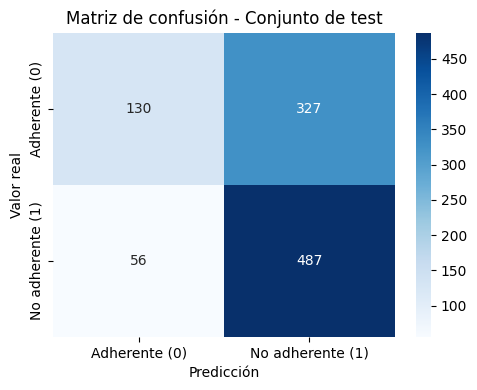

In [ ]:
# =========================================================
# EVALUACIÓN FINAL EN TEST DEL MEJOR MODELO
# =========================================================
# En este bloque se evalúa el modelo final seleccionado
# (XGBoost ajustado) sobre el conjunto de test.
#
# Es importante destacar que:
# - X_test e y_test no se han utilizado ni en el entrenamiento
#   ni en el ajuste de hiperparámetros
# - se utiliza el threshold óptimo encontrado previamente
#   en el conjunto de validación
#
# De este modo, esta evaluación permite estimar la capacidad
# real de generalización del modelo sobre datos no vistos.

# ---------------------------------------------------------
# Obtener probabilidades en test
# ---------------------------------------------------------
# Se calculan las probabilidades de pertenecer a la clase positiva
# (paciente no adherente = 1)
y_test_prob = best_xgb.predict_proba(X_test)[:, 1]

# ---------------------------------------------------------
# Aplicar el threshold óptimo
# ---------------------------------------------------------
# Se transforma la probabilidad en clase predicha utilizando
# el umbral seleccionado previamente en validation
y_test_pred = (y_test_prob >= best_threshold).astype(int)

# ---------------------------------------------------------
# Calcular métricas finales
# ---------------------------------------------------------
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_auc = roc_auc_score(y_test, y_test_prob)

# Mostrar resultados
print("=== RESULTADOS FINALES EN TEST ===")
print("Threshold aplicado:", round(best_threshold, 3))
print("Accuracy:", round(test_accuracy, 3))
print("Precision:", round(test_precision, 3))
print("Recall:", round(test_recall, 3))
print("F1-score:", round(test_f1, 3))
print("ROC-AUC:", round(test_auc, 3))

# ---------------------------------------------------------
# Matriz de confusión
# ---------------------------------------------------------
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)

plt.title("Matriz de confusión - Conjunto de test")
plt.xlabel("Predicción")
plt.ylabel("Valor real")

plt.tight_layout()
plt.show()

El modelo XGBoost ajustado se evalúa finalmente sobre el conjunto de test utilizando el umbral óptimo previamente determinado (threshold ≈ 0.42).

Los resultados obtenidos muestran un accuracy de 0.617 y un F1-score de 0.718, junto con un recall elevado (0.897) y una precision más moderada (0.598). La métrica ROC-AUC alcanza un valor de 0.697, lo que indica una capacidad discriminativa adecuada del modelo.

El alto valor de recall indica que el modelo es capaz de identificar correctamente la mayoría de los pacientes no adherentes (487 verdaderos positivos frente a 56 falsos negativos), lo que resulta especialmente relevante en este contexto.

Sin embargo, este comportamiento se produce a costa de un incremento en el número de falsos positivos (327), lo que reduce la precision. Este resultado es coherente con el uso de un umbral reducido, que favorece la clasificación de un mayor número de casos como positivos.

La matriz de confusión refleja claramente este equilibrio: mientras que se minimizan los falsos negativos, aumenta el número de pacientes clasificados incorrectamente como no adherentes.

En conjunto, estos resultados indican que el modelo presenta una buena capacidad de generalización y que el ajuste del umbral permite adaptar su comportamiento al objetivo del problema.

Dado que en este contexto resulta prioritario identificar a los pacientes no adherentes, se considera que el modelo con umbral ajustado ofrece un rendimiento adecuado, ya que maximiza la detección de estos casos, incluso a costa de un aumento en los falsos positivos.

## 4.5 Análisis del sobreajuste

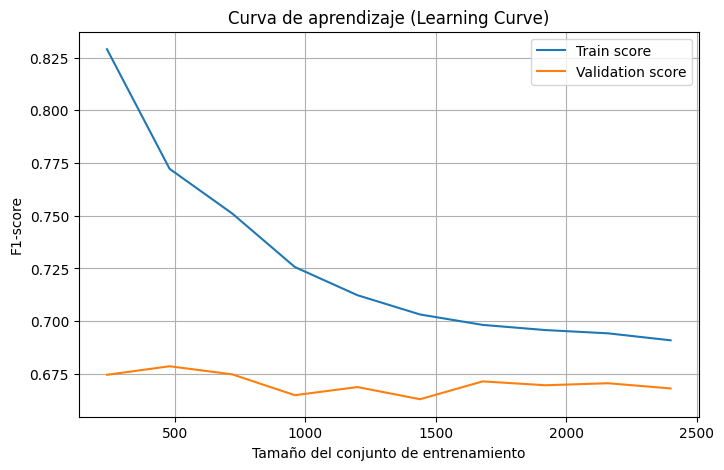

In [ ]:
from sklearn.model_selection import learning_curve

# Learning curve
train_sizes, train_scores, val_scores = learning_curve(
    best_xgb,
    X_train,
    y_train,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10)
)

# Medias
train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

# Gráfico
plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_mean, label="Train score")
plt.plot(train_sizes, val_mean, label="Validation score")

plt.xlabel("Tamaño del conjunto de entrenamiento")
plt.ylabel("F1-score")
plt.title("Curva de aprendizaje (Learning Curve)")
plt.legend()

plt.grid()
plt.show()

### Curva de aprendizaje

La curva de aprendizaje del modelo XGBoost representa la evolución del F1-score en los conjuntos de entrenamiento y validación en función del tamaño del conjunto de datos.

En primer lugar, se observa que el rendimiento en el conjunto de entrenamiento es inicialmente alto (en torno a 0.83) para tamaños pequeños de muestra, lo que indica que el modelo es capaz de ajustarse muy bien a los datos disponibles en estas condiciones. Sin embargo, a medida que aumenta el tamaño del conjunto de entrenamiento, el F1-score en entrenamiento disminuye progresivamente hasta estabilizarse alrededor de 0.69–0.70, reflejando una menor capacidad de ajuste perfecto a los datos conforme estos aumentan.

Por otro lado, el rendimiento en el conjunto de validación se mantiene relativamente estable, con valores comprendidos aproximadamente entre 0.66 y 0.68. A medida que aumenta el número de muestras, se observa una ligera mejora y posterior estabilización, lo que indica que el modelo se beneficia de una mayor cantidad de datos, aunque con rendimientos ya bastante consolidados.

La diferencia entre ambas curvas se reduce conforme aumenta el tamaño del conjunto de entrenamiento, lo que sugiere que el modelo no presenta un sobreajuste severo. Aunque existe una cierta brecha entre entrenamiento y validación, esta es moderada y tiende a estabilizarse, lo que indica un comportamiento consistente.

En conjunto, estos resultados sugieren que el modelo presenta un ligero grado de sobreajuste, pero mantiene una buena capacidad de generalización. Además, la tendencia de la curva de validación indica que, aunque el rendimiento mejora con más datos, este tiende a estabilizarse, lo que sugiere que futuras mejoras podrían requerir no solo más datos, sino también ajustes adicionales del modelo o incorporación de nuevas variables.

## 4.6. Resumen de los modelos supervisados

En este apartado se presenta una comparación global de los modelos de aprendizaje supervisado evaluados, analizando su rendimiento en base a las métricas consideradas. Dado que los modelos han sido entrenados bajo las mismas condiciones y sobre los mismos conjuntos de datos, esta comparación permite identificar sus diferencias en términos de capacidad predictiva y comportamiento frente al problema de la adherencia.

El análisis se centra en interpretar los resultados obtenidos para cada modelo, con el fin de proporcionar una visión completa de sus fortalezas y limitaciones en el contexto del estudio. Para ello, por un lado, se comparan los modelos en el conjunto de validación, lo que permite analizar su comportamiento inicial bajo las mismas condiciones y seleccionar el modelo más adecuado. Por otro lado, se calculan las métricas sobre el conjunto de test para el modelo final seleccionado, proporcionando una estimación realista de su rendimiento en datos no vistos.

De este modo, se obtiene una visión global del desempeño de los modelos supervisados, permitiendo comparar sus resultados tanto en la fase de validación como en la evaluación final, y facilitando la identificación del modelo más adecuado en función de los objetivos del problema.

In [ ]:
# =========================================================
# COMPARACIÓN DE TODOS LOS MODELOS EN VALIDACIÓN
# =========================================================

# Logistic Regression
y_pred_log = trained_pipelines["Logistic Regression"].predict(X_val)
y_prob_log = trained_pipelines["Logistic Regression"].predict_proba(X_val)[:, 1]

# Random Forest
y_pred_rf = trained_pipelines["Random Forest"].predict(X_val)
y_prob_rf = trained_pipelines["Random Forest"].predict_proba(X_val)[:, 1]

# MLP
y_pred_mlp = trained_pipelines["MLP"].predict(X_val)
y_prob_mlp = trained_pipelines["MLP"].predict_proba(X_val)[:, 1]

# XGBoost (inicial)
y_pred_xgb = trained_pipelines["XGBoost"].predict(X_val)
y_prob_xgb = trained_pipelines["XGBoost"].predict_proba(X_val)[:, 1]

# ---------------------------------------------------------
# Cálculo de métricas en validación
# ---------------------------------------------------------

# Logistic Regression
acc_log = accuracy_score(y_val, y_pred_log)
prec_log = precision_score(y_val, y_pred_log, zero_division=0)
rec_log = recall_score(y_val, y_pred_log, zero_division=0)
f1_log = f1_score(y_val, y_pred_log, zero_division=0)
roc_log = roc_auc_score(y_val, y_prob_log)

# Random Forest
acc_rf = accuracy_score(y_val, y_pred_rf)
prec_rf = precision_score(y_val, y_pred_rf, zero_division=0)
rec_rf = recall_score(y_val, y_pred_rf, zero_division=0)
f1_rf = f1_score(y_val, y_pred_rf, zero_division=0)
roc_rf = roc_auc_score(y_val, y_prob_rf)

# MLP
acc_mlp = accuracy_score(y_val, y_pred_mlp)
prec_mlp = precision_score(y_val, y_pred_mlp, zero_division=0)
rec_mlp = recall_score(y_val, y_pred_mlp, zero_division=0)
f1_mlp = f1_score(y_val, y_pred_mlp, zero_division=0)
roc_mlp = roc_auc_score(y_val, y_prob_mlp)

# XGBoost (inicial)
acc_xgb = accuracy_score(y_val, y_pred_xgb)
prec_xgb = precision_score(y_val, y_pred_xgb, zero_division=0)
rec_xgb = recall_score(y_val, y_pred_xgb, zero_division=0)
f1_xgb = f1_score(y_val, y_pred_xgb, zero_division=0)
roc_xgb = roc_auc_score(y_val, y_prob_xgb)

# XGBoost (ajustado)
acc_xgb_opt = accuracy_score(y_val, y_val_pred_thr)
prec_xgb_opt = precision_score(y_val, y_val_pred_thr, zero_division=0)
rec_xgb_opt = recall_score(y_val, y_val_pred_thr, zero_division=0)
f1_xgb_opt = f1_score(y_val, y_val_pred_thr, zero_division=0)
roc_xgb_opt = roc_auc_score(y_val, y_val_prob)

# ---------------------------------------------------------
# Tabla resumen en validación
# ---------------------------------------------------------
results_summary = pd.DataFrame([
    {
        "Modelo": "Logistic Regression",
        "Accuracy": acc_log,
        "Precision": prec_log,
        "Recall": rec_log,
        "F1-score": f1_log,
        "ROC-AUC": roc_log,
        "Observaciones": "Modelo lineal de referencia con buen recall y F1-score"
    },
    {
        "Modelo": "Random Forest",
        "Accuracy": acc_rf,
        "Precision": prec_rf,
        "Recall": rec_rf,
        "F1-score": f1_rf,
        "ROC-AUC": roc_rf,
        "Observaciones": "Rendimiento competitivo, aunque sin mejoras claras frente a modelos más simples"
    },
    {
        "Modelo": "MLP",
        "Accuracy": acc_mlp,
        "Precision": prec_mlp,
        "Recall": rec_mlp,
        "F1-score": f1_mlp,
        "ROC-AUC": roc_mlp,
        "Observaciones": "Mayor complejidad computacional sin mejora clara en rendimiento"
    },
    {
        "Modelo": "XGBoost (inicial)",
        "Accuracy": acc_xgb,
        "Precision": prec_xgb,
        "Recall": rec_xgb,
        "F1-score": f1_xgb,
        "ROC-AUC": roc_xgb,
        "Observaciones": "Buen rendimiento inicial antes del ajuste de hiperparámetros"
    },
    {
        "Modelo": "XGBoost (ajustado)",
        "Accuracy": acc_xgb_opt,
        "Precision": prec_xgb_opt,
        "Recall": rec_xgb_opt,
        "F1-score": f1_xgb_opt,
        "ROC-AUC": roc_xgb_opt,
        "Observaciones": "Mejor equilibrio entre métricas en validación, especialmente en recall"
    }
])

display(results_summary.round(3))

,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC,Observaciones
0,Logistic Regression,0.645,0.690,0.628,0.658,0.703,Modelo lineal de referencia con buen recall y ...
1,Random Forest,0.635,0.669,0.650,0.659,0.694,"Rendimiento competitivo, aunque sin mejoras cl..."
2,MLP,0.611,0.622,0.724,0.669,0.668,Mayor complejidad computacional sin mejora cla...
3,XGBoost (inicial),0.628,0.647,0.694,0.670,0.686,Buen rendimiento inicial antes del ajuste de h...
4,XGBoost (ajustado),0.634,0.613,0.886,0.724,0.704,"Mejor equilibrio entre métricas en validación,..."


In [ ]:
# =========================================================
# EVALUACIÓN FINAL DEL MODELO EN TEST
# =========================================================

# XGBoost (Final)
acc_xgb_final = accuracy_score(y_test, y_test_pred)
prec_xgb_final = precision_score(y_test, y_test_pred, zero_division=0)
rec_xgb_final = recall_score(y_test, y_test_pred, zero_division=0)
f1_xgb_final = f1_score(y_test, y_test_pred, zero_division=0)
roc_xgb_final = roc_auc_score(y_test, y_test_prob)


summary_final = pd.DataFrame([
  {
        "Modelo": " XGBoost (Final)",
        "Accuracy": acc_xgb_final,
        "Precision": prec_xgb_final,
        "Recall": rec_xgb_final,
        "F1-score": f1_xgb_final,
        "ROC-AUC": roc_xgb_final,
        "Observaciones": "Modelo ajustado y evaluado sobre datos no vistos"
    }
 ])

display(summary_final.round(3))

,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC,Observaciones
0,XGBoost (Final),0.617,0.598,0.897,0.718,0.697,Modelo ajustado y evaluado sobre datos no vistos


### Interpretación de resultados

Los resultados obtenidos en el conjunto de validación muestran que los distintos modelos presentan un rendimiento similar en términos de accuracy y ROC-AUC, lo que indica una capacidad moderada para discriminar entre pacientes adherentes y no adherentes. Sin embargo, se observan diferencias relevantes en métricas como precision, recall y F1-score, que permiten analizar con mayor profundidad el comportamiento de cada modelo.

En particular, la regresión logística destaca por su buen rendimiento en términos de accuracy (0.645), precision (0.690) y ROC-AUC (0.703), lo que indica una alta proporción de predicciones correctas y una buena capacidad de discriminación global. Por otro lado, la red neuronal (MLP) presenta el mayor valor de recall (0.724), lo que refleja una mayor capacidad para identificar correctamente a los pacientes no adherentes, aunque con una menor precisión.

El modelo XGBoost inicial muestra un rendimiento competitivo, destacando por obtener el mayor valor de F1-score (0.670), lo que indica un buen equilibrio entre precision y recall.

Tras el ajuste del modelo XGBoost y la optimización del umbral de decisión, se observa una mejora significativa en el recall (0.886 en validación), lo que indica una mayor capacidad para identificar correctamente a los pacientes no adherentes. Este incremento se produce a costa de una reducción en la precision y el accuracy, reflejando un mayor número de falsos positivos. No obstante, el F1-score también mejora (0.724), lo que indica un mejor equilibrio global entre precision y recall.

La evaluación final sobre el conjunto de test confirma la validez de este enfoque. El modelo XGBoost ajustado mantiene un recall elevado (0.897) y un F1-score de 0.718, lo que indica una buena capacidad de generalización. Asimismo, la métrica ROC-AUC se mantiene estable (0.697), lo que confirma que la capacidad discriminativa del modelo es consistente respecto a la fase de validación.

Desde el punto de vista aplicado, estos resultados son especialmente relevantes, ya que en el contexto de la adherencia al tratamiento resulta prioritario identificar a los pacientes no adherentes. En este sentido, la reducción de falsos negativos adquiere mayor importancia que el incremento de falsos positivos, justificando el uso de un umbral ajustado que prioriza el recall.

En conjunto, los resultados obtenidos confirman que el modelo XGBoost ajustado, junto con la optimización del umbral de decisión, mejora significativamente la detección de pacientes no adherentes sin comprometer en exceso el rendimiento global del modelo, proporcionando un equilibrio adecuado entre capacidad predictiva y relevancia clínica.

## 5. Aprendizaje No supervisado: segmentación de pacientes

Además del enfoque predictivo, se realiza un análisis de aprendizaje no supervisado con el objetivo de identificar grupos de pacientes con características similares. Este tipo de análisis permite descubrir patrones ocultos en los datos sin necesidad de una variable objetivo, lo que resulta especialmente útil para segmentar pacientes y comprender mejor los distintos perfiles de adherencia.

En primer lugar, se aplica el algoritmo K-Means para segmentar a los pacientes en distintos grupos. Para determinar el número óptimo de clusters, se emplean dos técnicas complementarias: el método del codo (Elbow Method), que analiza la variación de la inercia en función del número de clusters, y el coeficiente de silhouette, que evalúa la cohesión interna de los clusters y su separación respecto a otros grupos. El análisis conjunto de ambas métricas permite seleccionar un número adecuado de clusters que equilibre la simplicidad del modelo y la calidad de la segmentación.

Una vez determinado el número óptimo de clusters, se aplica el modelo K-Means y se analizan las características de cada grupo mediante el cálculo de estadísticas descriptivas, como la media de las variables. Este análisis permite identificar los perfiles predominantes en cada cluster y facilita su interpretación en términos de variables clínicas, demográficas y de comportamiento.

Con el objetivo de complementar este análisis, se emplea clustering jerárquico, representado mediante un dendrograma. Esta técnica permite visualizar la estructura de los datos y analizar cómo se agrupan progresivamente los pacientes en función de su similitud, proporcionando una visión global de la organización de los clusters y permitiendo contrastar el número de grupos obtenido previamente con K-Means.

Finalmente, se aplica un modelo de clustering aglomerativo utilizando el número de clusters previamente seleccionado. Este método, basado en un enfoque bottom-up, parte de clusters individuales que se van agrupando progresivamente en función de su similitud. A diferencia de K-Means, que asume clusters de forma esférica y depende de centroides, el clustering aglomerativo permite capturar estructuras más complejas en los datos.

La combinación de estos métodos permite comparar los resultados obtenidos y validar la consistencia de los clusters identificados, proporcionando una segmentación más robusta basada en diferentes enfoques metodológicos.

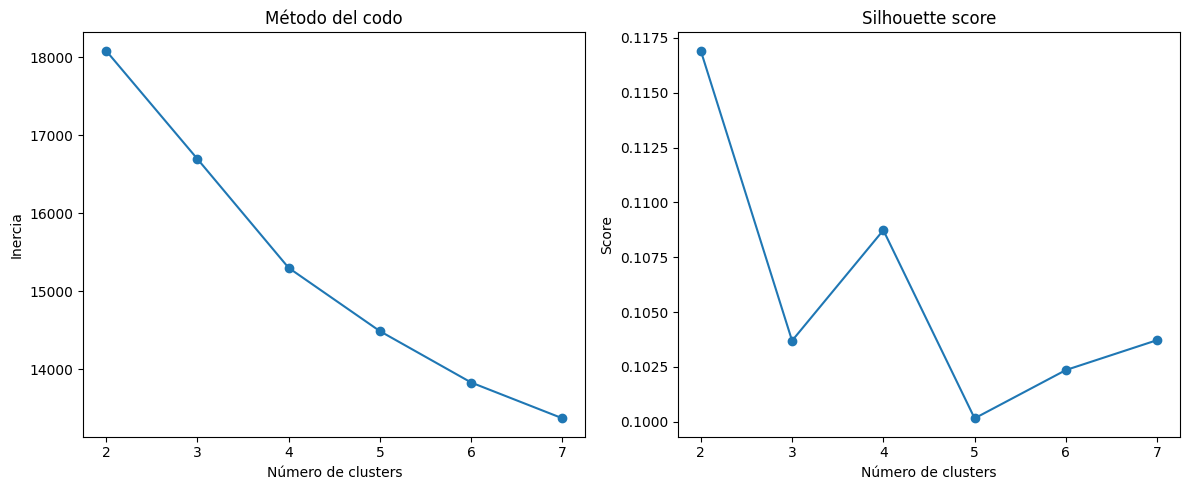

In [ ]:
# =========================================================
# CLUSTERING DE PACIENTES (K-MEANS)
# =========================================================

# Usamos los datos preprocesados (sin variable objetivo)
X_cluster = preprocessor.fit_transform(X)

# ---------------------------------------------------------
# Búsqueda del número óptimo de clusters (método del codo + silhouette)
# ---------------------------------------------------------
inertia = []
silhouette = []

K_range = range(2, 8)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_cluster)

    inertia.append(kmeans.inertia_)
    silhouette.append(silhouette_score(X_cluster, labels))

# ---------------------------------------------------------
# Gráficas
# ---------------------------------------------------------
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(K_range, inertia, marker='o')
plt.title("Método del codo")
plt.xlabel("Número de clusters")
plt.ylabel("Inercia")

plt.subplot(1,2,2)
plt.plot(K_range, silhouette, marker='o')
plt.title("Silhouette score")
plt.xlabel("Número de clusters")
plt.ylabel("Score")

plt.tight_layout()
plt.show()

En el proceso de clustering no se utiliza la variable objetivo, ya que el objetivo del aprendizaje no supervisado es identificar patrones y agrupaciones de forma independiente, sin conocimiento previo de la variable de adherencia.

Para determinar el número óptimo de clusters, se emplean el método del codo y el coeficiente silhouette. El método del codo muestra una disminución progresiva de la inercia a medida que aumenta el número de clusters, observándose un cambio en la pendiente a partir de valores cercanos a k = 4–5, lo que sugiere una posible zona de equilibrio entre complejidad y ajuste del modelo.

Por otro lado, el coeficiente silhouette alcanza su valor máximo en k = 2, lo que indicaría una mejor separación global entre dos grandes grupos. Sin embargo, este valor implica una segmentación excesivamente simple que puede resultar poco informativa desde el punto de vista interpretativo.

En cambio, el valor k = 4 presenta un coeficiente silhouette relativamente alto en comparación con el resto de valores (excepto k=2) y, al mismo tiempo, permite una segmentación más detallada de los pacientes. Esto facilita la identificación de perfiles diferenciados en función de características clínicas, demográficas y socioeconómicas.


In [ ]:
# Probamos con k=2
kmeans = KMeans(n_clusters=2, random_state=42)

clusters = kmeans.fit_predict(X_cluster)

# Añadimos al dataset original
df_cluster = X.copy()
df_cluster["Cluster"] = clusters

display(df_cluster.head())

,Age,Gender,Medication_Type,Dosage_mg,Previous_Adherence,Education_Level,Income,Social_Support_Level,Condition_Severity,Comorbidities_Count,Healthcare_Access,Mental_Health_Status,Insurance_Coverage,Cluster
0,57,Male,TypeA,136,1,High School,634934,Medium,Severe,3,Poor,Good,1,0
1,47,Male,TypeA,134,1,High School,297954,High,Moderate,3,Good,Good,1,0
2,59,Male,TypeC,89,1,High School,789337,High,Moderate,1,Good,Good,1,0
3,72,Male,TypeB,240,0,Postgraduate,267352,Low,Mild,2,Poor,Moderate,1,1
4,46,Male,TypeA,241,1,Postgraduate,718447,Medium,Mild,1,Poor,Good,1,0


In [ ]:
# Media de variables por cluster
cluster_summary = df_cluster.groupby("Cluster").mean(numeric_only=True)

for col in ["Gender", "Medication_Type", "Education_Level", "Social_Support_Level",
            "Condition_Severity", "Healthcare_Access", "Mental_Health_Status"]:
    print(f"\nDistribución de {col} por cluster:")
    display(pd.crosstab(df_cluster["Cluster"], df_cluster[col], normalize="index").round(2))

display(cluster_summary.round(2))


Distribución de Gender por cluster:


Gender,Female,Male,Other
Cluster,,,
0,0.5,0.48,0.02
1,0.5,0.49,0.01



Distribución de Medication_Type por cluster:


Medication_Type,TypeA,TypeB,TypeC
Cluster,,,
0,0.4,0.33,0.26
1,0.4,0.34,0.26



Distribución de Education_Level por cluster:


...


Distribución de Healthcare_Access por cluster:


Healthcare_Access,Average,Good,Poor
Cluster,,,
0,0.40,0.40,0.2
1,0.41,0.39,0.2



Distribución de Mental_Health_Status por cluster:


Mental_Health_Status,Good,Moderate,Poor
Cluster,,,
0,1.0,0.00,0.00
1,0.0,0.59,0.41


,Age,Dosage_mg,Previous_Adherence,Income,Comorbidities_Count,Insurance_Coverage
Cluster,,,,,,
0,49.67,200.71,0.70,499148.45,2.03,0.81
1,49.67,201.08,0.71,502705.94,2.00,0.79


### k=4

In [ ]:
# Probamos elegimos k=4
kmeans = KMeans(n_clusters=4, random_state=42)

clusters = kmeans.fit_predict(X_cluster)

# Añadimos al dataset original
df_cluster = X.copy()
df_cluster["Cluster"] = clusters

display(df_cluster.head())

,Age,Gender,Medication_Type,Dosage_mg,Previous_Adherence,Education_Level,Income,Social_Support_Level,Condition_Severity,Comorbidities_Count,Healthcare_Access,Mental_Health_Status,Insurance_Coverage,Cluster
0,57,Male,TypeA,136,1,High School,634934,Medium,Severe,3,Poor,Good,1,1
1,47,Male,TypeA,134,1,High School,297954,High,Moderate,3,Good,Good,1,0
2,59,Male,TypeC,89,1,High School,789337,High,Moderate,1,Good,Good,1,0
3,72,Male,TypeB,240,0,Postgraduate,267352,Low,Mild,2,Poor,Moderate,1,2
4,46,Male,TypeA,241,1,Postgraduate,718447,Medium,Mild,1,Poor,Good,1,2


In [ ]:
# Media de variables por cluster
cluster_summary = df_cluster.groupby("Cluster").mean(numeric_only=True)

for col in ["Gender", "Medication_Type", "Education_Level", "Social_Support_Level",
            "Condition_Severity", "Healthcare_Access", "Mental_Health_Status"]:
    print(f"\nDistribución de {col} por cluster:")
    display(pd.crosstab(df_cluster["Cluster"], df_cluster[col], normalize="index").round(2))

display(cluster_summary.round(2))


Distribución de Gender por cluster:


Gender,Female,Male,Other
Cluster,,,
0,0.49,0.50,0.01
1,0.49,0.49,0.02
2,0.51,0.48,0.01
3,0.51,0.48,0.01



Distribución de Medication_Type por cluster:


Medication_Type,TypeA,TypeB,TypeC
Cluster,,,
0,0.41,0.32,0.27
1,0.40,0.37,0.23
2,0.40,0.34,0.26
3,0.40,0.32,0.28



Distribución de Education_Level por cluster:


...


Distribución de Healthcare_Access por cluster:


Healthcare_Access,Average,Good,Poor
Cluster,,,
0,0.40,0.40,0.20
1,0.42,0.37,0.21
2,0.41,0.40,0.19
3,0.41,0.40,0.19



Distribución de Mental_Health_Status por cluster:


Mental_Health_Status,Good,Moderate,Poor
Cluster,,,
0,0.64,0.36,0.00
1,0.46,0.37,0.17
2,0.78,0.22,0.00
3,0.00,0.25,0.75


,Age,Dosage_mg,Previous_Adherence,Income,Comorbidities_Count,Insurance_Coverage
Cluster,,,,,,
0,49.86,201.65,0.68,508746.34,1.99,0.80
1,49.67,201.41,0.70,497996.68,1.95,0.79
2,49.61,200.53,0.72,492142.13,2.06,0.81
3,49.50,199.93,0.71,506157.51,2.05,0.80


El análisis de clustering permite identificar distintos perfiles de pacientes en función de sus características clínicas, socioeconómicas y psicológicas. Los resultados obtenidos muestran la existencia de cuatro grupos claramente diferenciados, lo que confirma la utilidad del enfoque no supervisado para segmentar a los pacientes más allá de la variable de adherencia.

En términos generales, se observa que las diferencias entre clusters no se explican tanto por variables demográficas (edad, género) o de tratamiento (tipo de medicación, dosis), que presentan valores muy similares entre grupos, sino principalmente por variables clínicas (gravedad de la enfermedad) y psicosociales (salud mental, nivel educativo y apoyo social).

Estos resultados sugieren que la adherencia al tratamiento no depende únicamente de factores médicos, sino también de variables psicológicas y sociales, lo que refuerza la necesidad de un enfoque multidimensional en su análisis.

### **Cluster 0: perfil estable con bajo nivel educativo**

El cluster 0 agrupa pacientes con una condición clínica predominantemente leve o moderada (64% mild, 36% moderate) y un buen estado de salud mental (64% good). Este grupo presenta una adherencia previa moderada (0.68), lo que sugiere un comportamiento relativamente estable.

Sin embargo, destaca un rasgo diferenciador importante: el nivel educativo homogéneamente bajo, con un 100% de pacientes con estudios de nivel High School. Este factor puede limitar la comprensión del tratamiento y afectar indirectamente a la adherencia.

Este perfil sugiere que, aunque no se trata de un grupo de alto riesgo clínico, podría beneficiarse de intervenciones centradas en la educación sanitaria y la mejora de la comprensión del tratamiento.

### **Cluster 1: perfil clínico de alto riesgo**

El cluster 1 representa el grupo de mayor riesgo clínico, caracterizado por una elevada gravedad de la enfermedad (89% severe). Además, presenta un estado de salud mental más deteriorado en comparación con otros clusters, con una mayor proporción de pacientes en categorías moderate y poor.

Aunque la adherencia previa (0.70) no es la más baja, la combinación de alta gravedad clínica y peor estado psicológico convierte a este grupo en especialmente vulnerable.

Este perfil requiere intervenciones prioritarias, orientadas tanto al control clínico de la enfermedad como al apoyo psicológico, ya que ambos factores pueden influir de forma conjunta en la adherencia.

### **Cluster 2: perfil óptimo**

El cluster 2 representa el grupo con mejores condiciones generales. Se caracteriza por un estado de salud mental muy positivo (78% good) y una baja gravedad de la enfermedad (65% mild).

Además, presenta la mayor adherencia previa (0.72), así como un nivel educativo elevado, con una alta proporción de pacientes con estudios de grado y posgrado.

Este perfil corresponde a pacientes con un comportamiento favorable respecto al seguimiento del tratamiento. En este caso, las estrategias deben centrarse en el mantenimiento de los hábitos de adherencia, más que en intervenciones intensivas.

### **Cluster 3: riesgo psicológico**

El cluster 3 se caracteriza principalmente por un deterioro significativo del estado de salud mental, con un 75% de pacientes en la categoría poor. A diferencia del cluster 1, estos pacientes no presentan una elevada gravedad clínica (predominan niveles leves y moderados).

A pesar de que la adherencia previa es relativamente alta (0.71), este perfil sugiere la presencia de factores psicológicos que pueden afectar al comportamiento del paciente a medio o largo plazo.

Este grupo pone de manifiesto que la adherencia no depende únicamente de la gravedad de la enfermedad, sino también del bienestar emocional. Por tanto, las intervenciones deberían centrarse en el apoyo psicológico y la mejora del estado mental, más que en el tratamiento clínico.

### Conclusión

En conjunto, la segmentación obtenida permite identificar perfiles diferenciados de pacientes, evidenciando que la adherencia al tratamiento está influida no solo por factores clínicos, sino también por variables psicológicas, educativas y sociales.

Los resultados muestran que existen perfiles de riesgo diferenciados:

- Riesgo clínico (Cluster 1)
- Riesgo psicológico (Cluster 3)
- Perfil estable pero mejorable (Cluster 0)
- Perfil óptimo (Cluster 2)

Esta clasificación resulta especialmente útil para el diseño de estrategias de intervención personalizadas, adaptadas a las características de cada grupo de pacientes, lo que puede contribuir a mejorar la adherencia al tratamiento de forma más eficaz.

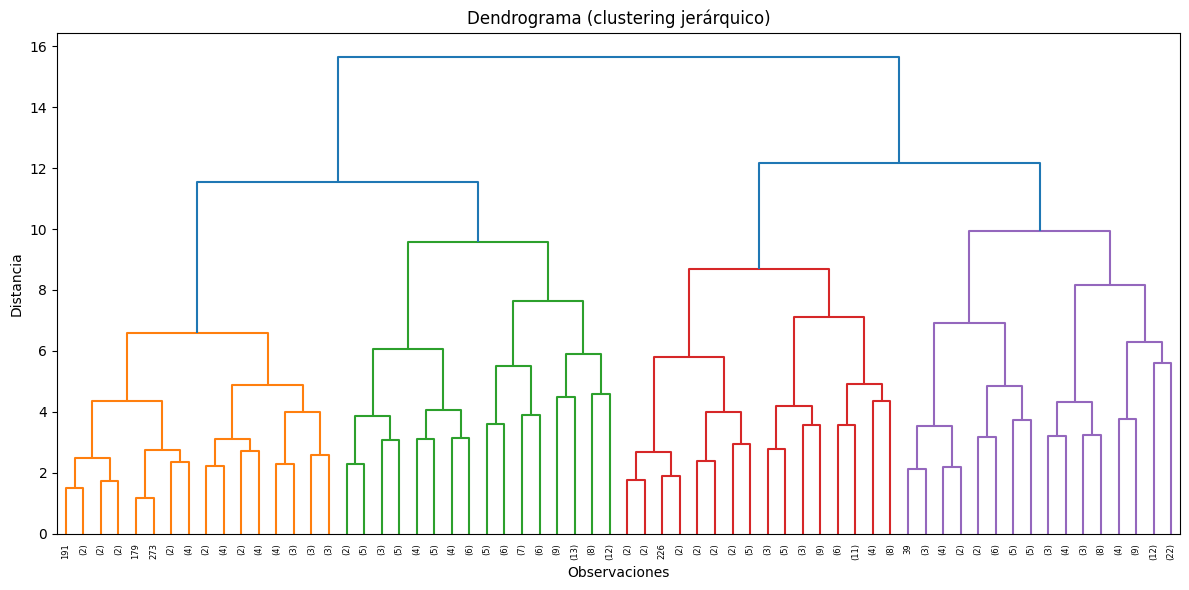

In [ ]:
# =========================================================
# DENDROGRAMA - CLUSTERING JERÁRQUICO
# =========================================================
# Usar datos transformados por el pipeline:
# - escalados (MinMaxScaler)
# - codificados (OneHot / Ordinal)
sample_size = 300
X_sample = X_cluster[:sample_size]

# Método Ward
linked = linkage(X_sample, method='ward')

# Plot
plt.figure(figsize=(12, 6))

dendrogram(
    linked,
    truncate_mode='level',  # simplifica el gráfico
    p=5                     # niveles a mostrar
)

plt.title("Dendrograma (clustering jerárquico)")
plt.xlabel("Observaciones")
plt.ylabel("Distancia")

plt.tight_layout()
plt.show()

El dendrograma obtenido mediante clustering jerárquico muestra la estructura de agrupación de los pacientes en función de su similitud, permitiendo analizar cómo se van fusionando progresivamente los distintos grupos a medida que aumenta la distancia.

A partir de su análisis, se observa la existencia de varias agrupaciones naturales, aunque la separación entre ellas no es completamente marcada. En particular, se identifican saltos en la distancia de fusión a partir de valores cercanos a 10–12, lo que sugiere la presencia de varios grupos diferenciados.

Un corte del dendrograma en una distancia aproximada de 12 permite obtener cuatro clusters, lo que resulta coherente con la solución previamente obtenida mediante el algoritmo K-Means. Esta coincidencia entre ambos métodos refuerza la validez de la segmentación realizada.

No obstante, el dendrograma también muestra que algunos clusters se encuentran relativamente próximos entre sí, lo que indica que la separación entre grupos no es completamente nítida. Este comportamiento es consistente con los valores moderados del coeficiente silhouette, que reflejan una estructura de datos con cierto grado de solapamiento entre clusters.

En conjunto, el análisis jerárquico confirma que la elección de k = 4 constituye un compromiso adecuado entre la calidad de la agrupación y la interpretabilidad de los resultados, proporcionando una segmentación coherente con la obtenida mediante otros métodos.




In [ ]:
# =========================================================
# AGGLOMERATIVE CLUSTERING
# =========================================================

agg = AgglomerativeClustering(n_clusters=4)

clusters_hier = agg.fit_predict(X_cluster)

df_cluster["Cluster_Hier"] = clusters_hier

df_cluster.head(10)

,Age,Gender,Medication_Type,Dosage_mg,Previous_Adherence,Education_Level,Income,Social_Support_Level,Condition_Severity,Comorbidities_Count,Healthcare_Access,Mental_Health_Status,Insurance_Coverage,Cluster,Cluster_Hier
0,57,Male,TypeA,136,1,High School,634934,Medium,Severe,3,Poor,Good,1,1,2
1,47,Male,TypeA,134,1,High School,297954,High,Moderate,3,Good,Good,1,0,2
2,59,Male,TypeC,89,1,High School,789337,High,Moderate,1,Good,Good,1,0,2
3,72,Male,TypeB,240,0,Postgraduate,267352,Low,Mild,2,Poor,Moderate,1,2,3
4,46,Male,TypeA,241,1,Postgraduate,718447,Medium,Mild,1,Poor,Good,1,2,0
5,46,Female,TypeA,242,1,Graduate,389971,Medium,Mild,1,Good,Good,1,2,0
6,73,Female,TypeA,215,1,High School,532785,Low,Mild,1,Poor,Good,1,0,3
7,61,Female,TypeC,93,1,High School,545197,Low,Mild,0,Poor,Good,1,0,3
8,42,Male,TypeA,148,1,Postgraduate,539541,High,Moderate,1,Poor,Good,1,2,0
9,58,Male,TypeC,208,1,Postgraduate,634899,Low,Mild,2,Average,Good,1,2,0


In [ ]:
pd.crosstab(df_cluster["Cluster"], df_cluster["Cluster_Hier"])

Cluster_Hier,0,1,2,3
Cluster,,,,
0,396,160,200,570
1,4,421,685,10
2,712,98,322,330
3,25,854,29,184


Se aplica clustering jerárquico mediante el algoritmo aglomerativo con el objetivo de contrastar la segmentación obtenida previamente con K-Means.

Para ello, se comparan las asignaciones de clusters de ambos métodos mediante una tabla de contingencia. Los resultados muestran que existe una correspondencia parcial entre los clusters generados por ambos algoritmos. En particular, algunos grupos presentan una asociación clara (por ejemplo, el cluster 1 de K-Means se corresponde mayoritariamente con un único cluster jerárquico), mientras que otros aparecen más distribuidos entre varios grupos.

Este comportamiento indica que la estructura de los datos no presenta una segmentación completamente definida y que los límites entre clusters no son estrictamente claros. Esta situación es habitual en problemas reales con datos heterogéneos, donde las observaciones pueden compartir características de distintos grupos.

Asimismo, las diferencias observadas entre ambos métodos se explican por la propia naturaleza de los algoritmos utilizados. Mientras que K-Means busca particiones basadas en centroides y asume clusters de forma aproximadamente esférica, el clustering jerárquico aglomerativo no impone esta restricción y permite capturar relaciones más complejas entre los datos.

Por tanto, más que una falta de validez, la divergencia parcial entre ambos métodos refleja la complejidad inherente del problema y la existencia de estructuras de datos no perfectamente separables.

En este contexto, la segmentación obtenida mediante K-Means se considera adecuada, ya que proporciona clusters relativamente equilibrados y fácilmente interpretables, lo que resulta especialmente útil para el análisis de perfiles de pacientes y la definición de estrategias de intervención.

## 6. Técnicas de interpretabilidad

El análisis de interpretabilidad se realiza principalmente sobre el conjunto de validación, ya que es el mismo conjunto utilizado en la comparación entre los distintos modelos. De este modo, se mantiene la coherencia en el análisis y se facilita la comparación de la relevancia de las variables entre los diferentes enfoques.

En primer lugar, se interpretan los coeficientes del modelo de regresión logística, lo que permite analizar la relación entre cada variable y la probabilidad de no adherencia. En este contexto, el signo de los coeficientes indica si una variable incrementa o reduce la probabilidad de que un paciente no siga correctamente el tratamiento, mientras que su magnitud refleja la intensidad de dicho efecto.

A continuación, se analiza la importancia de variables en el modelo Random Forest mediante la técnica de feature importance, que permite identificar qué variables tienen mayor peso en la toma de decisiones del modelo. Esta medida proporciona una visión global de la relevancia de cada variable, aunque no permite interpretar directamente el sentido de su efecto.

Finalmente, se aplica SHAP (SHapley Additive Explanations) sobre el modelo XGBoost ajustado, con el objetivo de obtener una interpretación más detallada de su comportamiento. SHAP permite calcular la importancia global de las variables, así como analizar la contribución individual de cada una de ellas en las predicciones. De este modo, es posible entender no solo qué variables son relevantes, sino también cómo influyen en cada predicción concreta del modelo.

Este enfoque combinado permite analizar la relevancia de las variables desde distintas perspectivas: interpretabilidad directa en modelos lineales, importancia global en modelos basados en árboles e interpretación local y global en modelos complejos. En conjunto, este análisis facilita una comprensión más completa de los factores que influyen en la no adherencia al tratamiento y refuerza la robustez de las conclusiones obtenidas.

In [ ]:
# =========================================================
# DICCIONARIOS DE RENOMBRADO
# =========================================================

# Para SHAP: nombres limpios pero SIN agrupar dummies
rename_dict_shap = {
    "scale__Previous_Adherence": "Previous_Adherence",
    "ord__Condition_Severity": "Condition_Severity",
    "ord__Mental_Health_Status": "Mental_Health",
    "ord__Healthcare_Access": "Healthcare_Access",
    "ord__Social_Support_Level": "Social_Support",
    "scale__Insurance_Coverage": "Insurance_Coverage",
    "ord__Education_Level": "Education_Level",
    "scale__Age": "Age",
    "scale__Dosage_mg": "Dosage_mg",
    "onehot__Medication_Type_TypeB": "Medication_B",
    "onehot__Medication_Type_TypeC": "Medication_C",
    "scale__Comorbidities_Count": "Comorbidities",
    "scale__Income": "Income",
    "onehot__Gender_Male": "Gender_Male",
    "onehot__Gender_Other": "Gender_Other"
}

# Para agrupar en tablas/gráficos de importancia
rename_dict_grouped = {
    "scale__Previous_Adherence": "Previous_Adherence",
    "ord__Condition_Severity": "Condition_Severity",
    "ord__Mental_Health_Status": "Mental_Health",
    "ord__Healthcare_Access": "Healthcare_Access",
    "ord__Social_Support_Level": "Social_Support",
    "scale__Insurance_Coverage": "Insurance_Coverage",
    "ord__Education_Level": "Education_Level",
    "scale__Age": "Age",
    "scale__Dosage_mg": "Dosage_mg",
    "onehot__Medication_Type_TypeB": "Medication_Type",
    "onehot__Medication_Type_TypeC": "Medication_Type",
    "scale__Comorbidities_Count": "Comorbidities",
    "scale__Income": "Income",
    "onehot__Gender_Male": "Gender",
    "onehot__Gender_Other": "Gender"
}

,Variable,Coeficiente,Abs
11,Previous_Adherence,-1.184347,1.184347
3,Dosage_mg,0.544868,0.544868
8,Insurance_Coverage,-0.461792,0.461792
0,Age,0.416765,0.416765
7,Income,0.366331,0.366331
1,Comorbidities,0.307624,0.307624
10,Mental_Health,-0.289916,0.289916
12,Social_Support,-0.263202,0.263202
2,Condition_Severity,0.235204,0.235204
4,Education_Level,-0.234040,0.234040


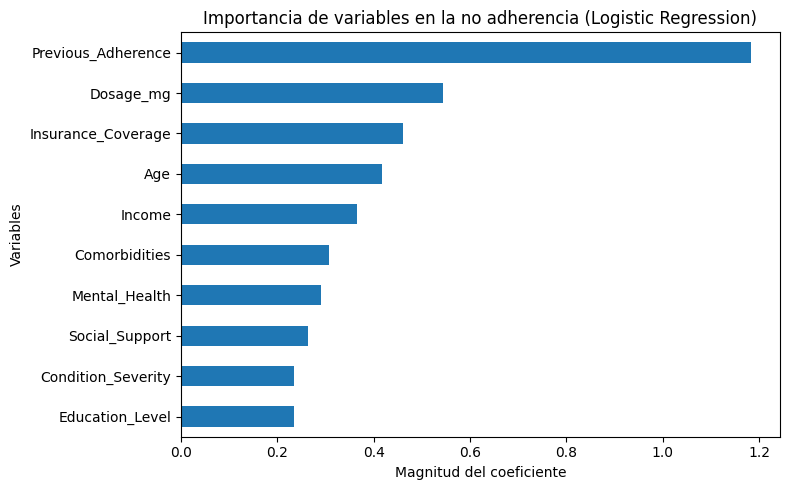

In [ ]:
# =========================================================
# INTERPRETABILIDAD - LOGISTIC REGRESSION
# =========================================================

# Extraer modelo y preprocesador
lr_model = trained_pipelines["Logistic Regression"].named_steps["model"]
preprocessor = trained_pipelines["Logistic Regression"].named_steps["preprocessing"]

# Obtener nombres de variables transformadas
feature_names = preprocessor.get_feature_names_out()

# Obtener coeficientes
coefficients = lr_model.coef_[0]

# Crear DataFrame
coef_df = pd.DataFrame({
    "Variable": feature_names,
    "Coeficiente": coefficients
})

# Renombramos columnas
coef_df["Variable"] = coef_df["Variable"].replace(rename_dict_grouped)

# ---------------------------------------------------------
# Agrupar variables dummy
# ---------------------------------------------------------
coef_df["Abs"] = coef_df["Coeficiente"].abs()

coef_grouped = coef_df.groupby("Variable", as_index=False).agg({
    "Coeficiente": "sum",
    "Abs": "sum"
})

# Ordenar por importancia
coef_grouped = coef_grouped.sort_values(by="Abs", ascending=False)

display(coef_grouped.head(10))

# Gráfico
coef_grouped.set_index("Variable")["Abs"].head(10).plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Importancia de variables en la no adherencia (Logistic Regression)")
plt.xlabel("Magnitud del coeficiente")
plt.ylabel("Variables")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


,Variable,Importance
7,Income,0.165422
3,Dosage_mg,0.165120
0,Age,0.147693
11,Previous_Adherence,0.100706
1,Comorbidities,0.074454
4,Education_Level,0.051925
12,Social_Support,0.050111
2,Condition_Severity,0.048387
10,Mental_Health,0.046916
9,Medication_Type,0.046509


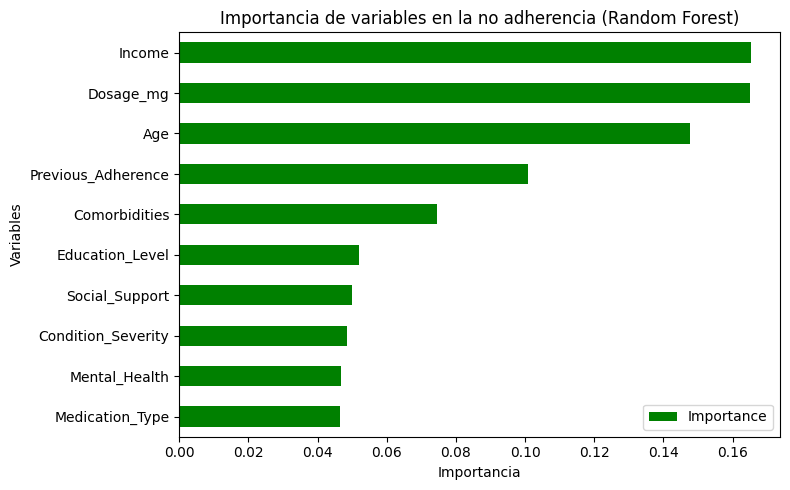

In [ ]:
# =========================================================
# FEATURE IMPORTANCE - RANDOM FOREST
# =========================================================

rf_model = trained_pipelines["Random Forest"].named_steps["model"]
rf_preprocessor = trained_pipelines["Random Forest"].named_steps["preprocessing"]

feature_names = rf_preprocessor.get_feature_names_out()

rf_importance = rf_model.feature_importances_

rf_df = pd.DataFrame({
    "Variable": feature_names,
    "Importance": rf_importance
})

# Renombrar igual que antes
rf_df["Variable"] = rf_df["Variable"].replace(rename_dict_grouped)

# Agrupar variables dummy
rf_grouped = rf_df.groupby("Variable", as_index=False)["Importance"].sum()

# Ordenar
rf_grouped = rf_grouped.sort_values(by="Importance", ascending=False)

display(rf_grouped.head(10))

# Gráfico
rf_grouped.set_index("Variable").head(10).plot(
    kind="barh",
    figsize=(8,5),
    color="green"
)

plt.title("Importancia de variables en la no adherencia (Random Forest)")
plt.xlabel("Importancia")
plt.ylabel("Variables")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

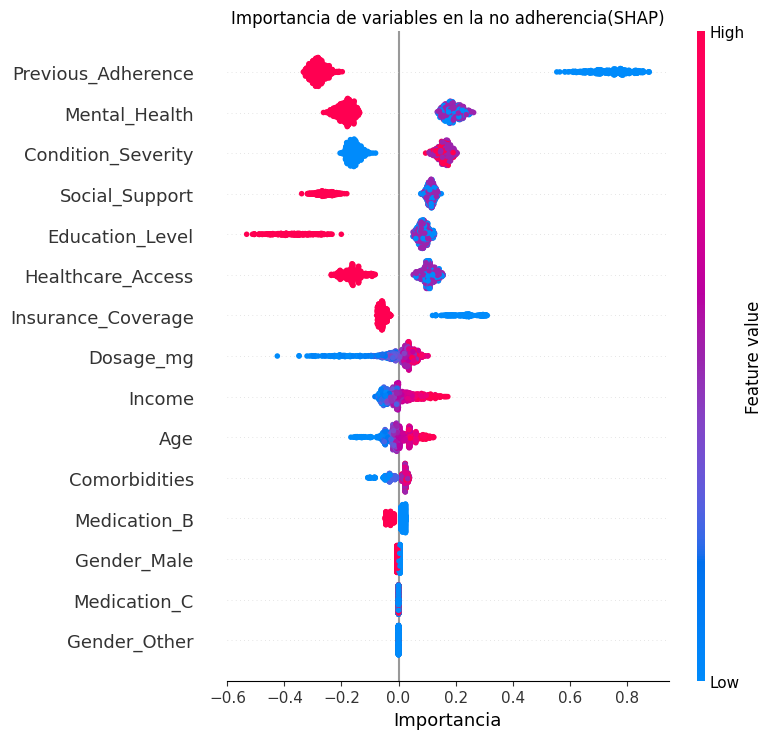

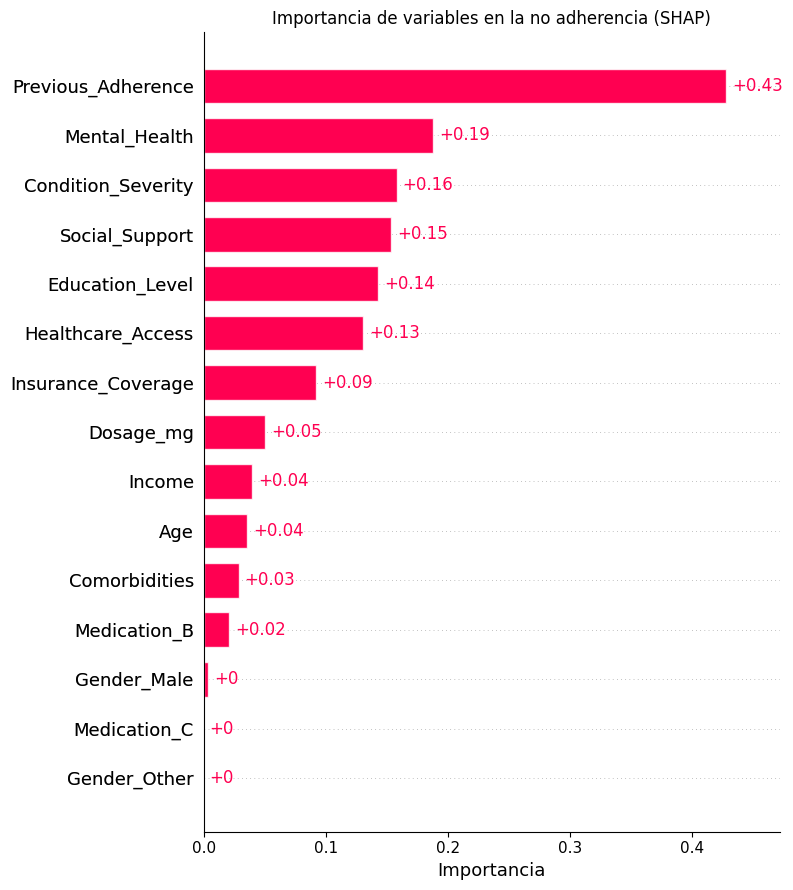

In [ ]:
# =========================================================
# INTERPRETABILIDAD DEL MODELO (SHAP)
# =========================================================

# Extraemos modelo y preprocesador
model = best_xgb.named_steps["model"]
preprocessor_fitted = best_xgb.named_steps["preprocessing"]

# Transformamos X_val
X_processed = preprocessor_fitted.transform(X_val)

# Nombres originales de variables transformadas
feature_names = preprocessor_fitted.get_feature_names_out()

# Convertimos a DataFrame
X_processed_df = pd.DataFrame(X_processed, columns=feature_names)

# Renombramos columnas para que el gráfico sea más legible
X_processed_df = X_processed_df.rename(columns=rename_dict_shap)

# SHAP
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_processed_df)

# ---------------------------------------------------------
# Gráfico resumen SHAP
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_processed_df, max_display=15, show=False)
plt.xlabel("Importancia")
plt.title("Importancia de variables en la no adherencia(SHAP)")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Gráfico de barras SHAP
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))
shap.plots.bar(shap_values, max_display=15, show=False)
plt.title("Importancia de variables en la no adherencia (SHAP)")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()

,Variable,Importance
11,Previous_Adherence,0.428278
10,Mental_Health,0.187974
2,Condition_Severity,0.158057
12,Social_Support,0.153763
4,Education_Level,0.142660
6,Healthcare_Access,0.130412
8,Insurance_Coverage,0.092321
3,Dosage_mg,0.050056
7,Income,0.039511
0,Age,0.035681


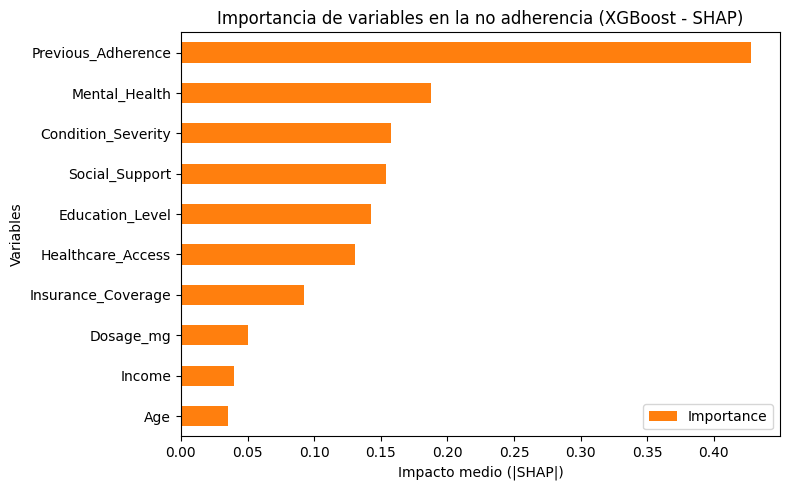

In [ ]:
# =========================================================
# IMPORTANCIA GLOBAL - XGBOOST (SHAP)
# =========================================================

# Importancia SHAP
shap_importance = np.abs(shap_values.values).mean(axis=0)

shap_df = pd.DataFrame({
    "Variable": X_processed_df.columns,
    "Importance": shap_importance
})

# ---------------------------------------------------------
# Agrupar variables dummy
# ---------------------------------------------------------
shap_df["Variable"] = shap_df["Variable"].replace({
    "Medication_B": "Medication_Type",
    "Medication_C": "Medication_Type",
    "Gender_Male": "Gender",
    "Gender_Other": "Gender"
})

shap_grouped = shap_df.groupby("Variable", as_index=False)["Importance"].sum()

# Ordenar por importancia
shap_grouped = shap_grouped.sort_values(by="Importance", ascending=False)

display(shap_grouped.head(10))

# Gráfico
shap_grouped.set_index("Variable").head(10).plot(
    kind="barh",
    figsize=(8,5),
    color="tab:orange"
)

plt.title("Importancia de variables en la no adherencia (XGBoost - SHAP)")
plt.xlabel("Impacto medio (|SHAP|)")
plt.ylabel("Variables")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

,Variable,LR,RF,XGB_SHAP,LR_norm,RF_norm,XGB_norm
0,Previous_Adherence,1.184,0.101,0.428,0.241,0.101,0.291
1,Dosage_mg,0.545,0.165,0.050,0.111,0.165,0.034
4,Income,0.366,0.165,0.040,0.074,0.165,0.027
3,Age,0.417,0.148,0.036,0.085,0.148,0.024
6,Mental_Health,0.290,0.047,0.188,0.059,0.047,0.128
7,Social_Support,0.263,0.050,0.154,0.053,0.050,0.104
8,Condition_Severity,0.235,0.048,0.158,0.048,0.048,0.107
9,Education_Level,0.234,0.052,0.143,0.048,0.052,0.097
2,Insurance_Coverage,0.462,0.025,0.092,0.094,0.025,0.063
11,Healthcare_Access,0.210,0.046,0.130,0.043,0.046,0.089


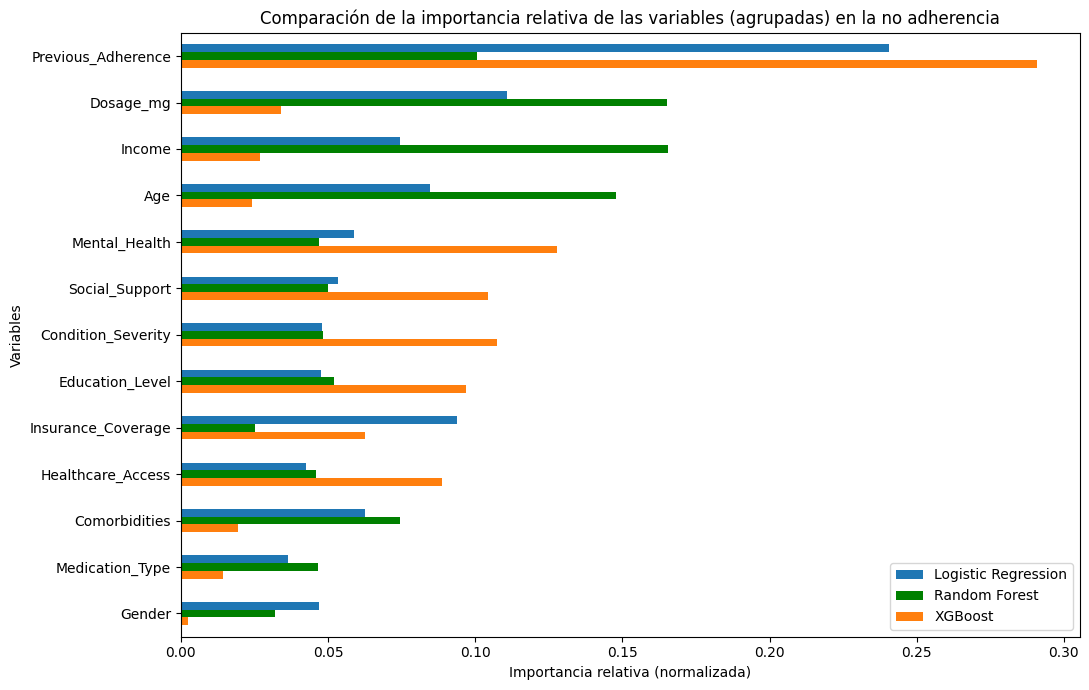

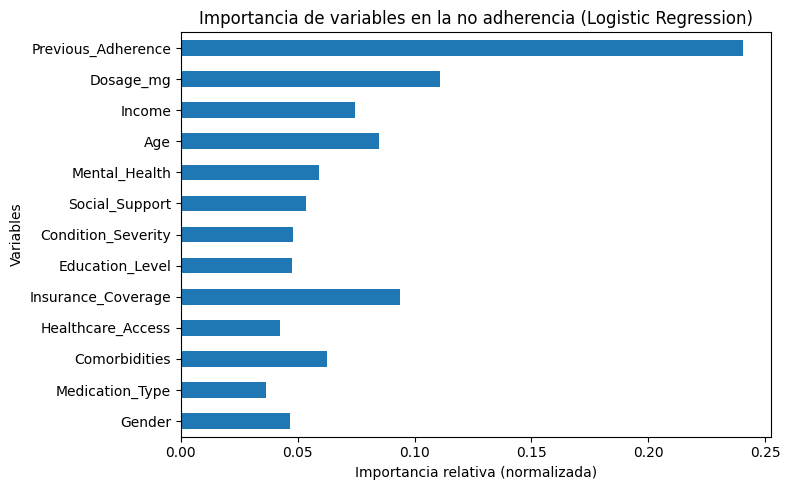

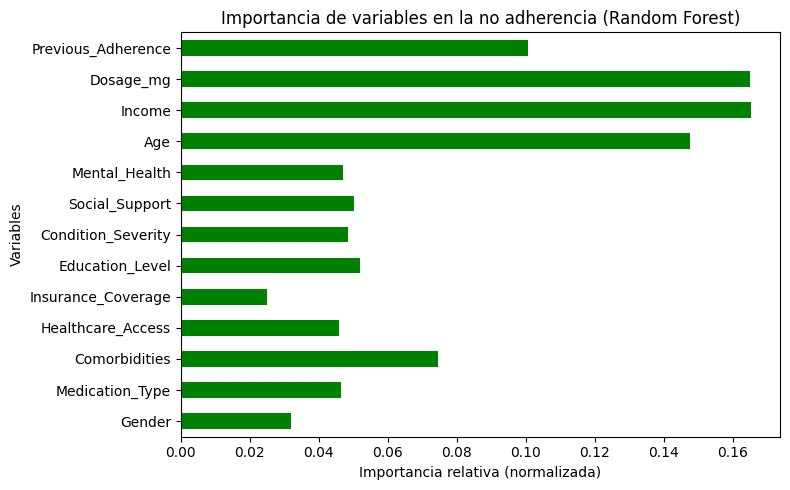

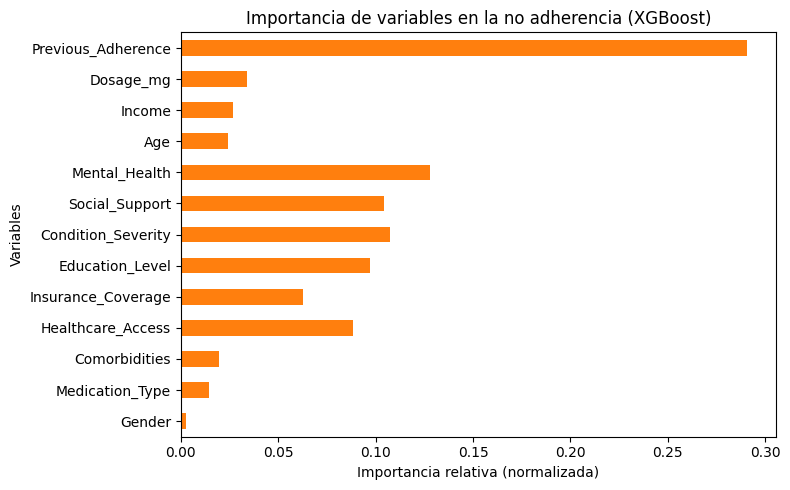

In [ ]:
# =========================================================
# COMPARACIÓN DE IMPORTANCIA DE VARIABLES:
# LOGISTIC REGRESSION vs RANDOM FOREST vs XGBOOST
# =========================================================
# En este bloque se comparan las importancias de las variables
# obtenidas previamente para los tres modelos:
# - Logistic Regression
# - Random Forest
# - XGBoost (SHAP)
#
# Se parte de las tablas ya calculadas:
# - coef_grouped
# - rf_grouped
# - shap_grouped

# ---------------------------------------------------------
# Renombrar columnas para unificar
# ---------------------------------------------------------
lr_compare = coef_grouped[["Variable", "Abs"]].rename(columns={"Abs": "LR"})
rf_compare = rf_grouped[["Variable", "Importance"]].rename(columns={"Importance": "RF"})
xgb_compare = shap_grouped[["Variable", "Importance"]].rename(columns={"Importance": "XGB_SHAP"})

# ---------------------------------------------------------
# Unir las importancias de los tres modelos
# ---------------------------------------------------------
compare_df = lr_compare.merge(rf_compare, on="Variable", how="inner")
compare_df = compare_df.merge(xgb_compare, on="Variable", how="inner")

# ---------------------------------------------------------
# Normalizar las importancias
# ---------------------------------------------------------
# Se normaliza cada columna entre 0 y 1 para comparar
# la importancia relativa dentro de cada modelo.
compare_df["LR_norm"] = compare_df["LR"] / compare_df["LR"].sum()
compare_df["RF_norm"] = compare_df["RF"] / compare_df["RF"].sum()
compare_df["XGB_norm"] = compare_df["XGB_SHAP"] / compare_df["XGB_SHAP"].sum()

# ---------------------------------------------------------
# Ordenar variables por importancia media
# ---------------------------------------------------------
compare_df["mean_importance"] = compare_df[["LR_norm", "RF_norm", "XGB_norm"]].mean(axis=1)
compare_df = compare_df.sort_values(by="mean_importance", ascending=False)

# ---------------------------------------------------------
# Mostrar tabla final
# ---------------------------------------------------------
display(
    compare_df[
        ["Variable", "LR", "RF", "XGB_SHAP", "LR_norm", "RF_norm", "XGB_norm"]
    ].round(3)
)

# ---------------------------------------------------------
# Gráfico comparativo conjunto
# ---------------------------------------------------------
compare_df.set_index("Variable")[["LR_norm", "RF_norm", "XGB_norm"]].plot(
    kind="barh",
    figsize=(11, 7),
    color=["tab:blue", "green", "tab:orange"]
)

plt.title("Comparación de la importancia relativa de las variables (agrupadas) en la no adherencia")
plt.xlabel("Importancia relativa (normalizada)")
plt.ylabel("Variables")
plt.legend(["Logistic Regression", "Random Forest", "XGBoost"])

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Gráfico individual - Logistic Regression
# ---------------------------------------------------------
compare_df.set_index("Variable")["LR_norm"].plot(
    kind="barh",
    figsize=(8, 5),
    color="tab:blue"
)

plt.title("Importancia de variables en la no adherencia (Logistic Regression)")
plt.xlabel("Importancia relativa (normalizada)")
plt.ylabel("Variables")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Gráfico individual - Random Forest
# ---------------------------------------------------------
compare_df.set_index("Variable")["RF_norm"].plot(
    kind="barh",
    figsize=(8, 5),
    color="green"
)

plt.title("Importancia de variables en la no adherencia (Random Forest)")
plt.xlabel("Importancia relativa (normalizada)")
plt.ylabel("Variables")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Gráfico individual - XGBoost
# ---------------------------------------------------------
compare_df.set_index("Variable")["XGB_norm"].plot(
    kind="barh",
    figsize=(8, 5),
    color="tab:orange"
)

plt.title("Importancia de variables en la no adherencia (XGBoost)")
plt.xlabel("Importancia relativa (normalizada)")
plt.ylabel("Variables")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Interpretación de la importancia de variables

Aunque existe un claro consenso entre los modelos en la relevancia de la variable Previous_Adherence, se observan diferencias en cómo cada modelo distribuye la importancia del resto de variables.

En particular, tanto la regresión logística como XGBoost identifican Previous_Adherence como la variable más influyente, lo que indica que el comportamiento previo del paciente es un factor clave en la predicción de la no adherencia. Este resultado es coherente, ya que un paciente que ha mostrado dificultades en el pasado tiene mayor probabilidad de no seguir correctamente el tratamiento en el futuro.

En el caso de Random Forest, la importancia no se concentra tanto en una única variable, sino que se reparte entre varias, como Dosage_mg, Income, Age o Comorbidities. Esto sugiere que el modelo tiene en cuenta una combinación de factores y no depende de una única variable dominante, captando relaciones más complejas entre las variables.

Por otro lado, en XGBoost (SHAP) también se observa una contribución relevante de variables como Mental_Health, Social_Support o Condition_Severity, lo que indica que no solo influyen factores clínicos, sino también aspectos psicológicos y sociales en la adherencia al tratamiento.

Estas diferencias reflejan la naturaleza de los modelos: mientras que la regresión logística identifica relaciones más directas, y XGBoost destaca las variables con mayor impacto global, Random Forest distribuye la importancia entre varios factores.

En conjunto, este análisis refuerza la idea de que la adherencia al tratamiento es un fenómeno multifactorial, en el que no solo influyen variables clínicas, sino también factores sociales y psicológicos.